# COF Seasonal and Zonal-Mean Precipitation Maps

## Purpose
This notebook computes and plots seasonal (DJF/MAM/JJA/SON) global maps and zonal-mean (latitude-band) profiles of mesoscale convective system (MCS) precipitation contribution — isolated and co-occurring with atmospheric rivers (AR) and extratropical cyclones (ETC) — across multiple observational and global storm-resolving model (GSRM) sources, with land/ocean splits and observation-vs-model difference maps.

## Input Data
Monthly precipitation statistics on a HEALPix zoom 8 grid, one NetCDF file per source. The notebook reads the CFS copy, which is identical file by file to the production copy in
`/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/`:
```
/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/monthly/<source>_monthly_rainmap_cof_hp8_v1.nc
```
These files are generated by:
- **Python script:** `waccem/gsrm_cooccurrencefeature/scripts/calc_monthly_rainmap_by_cof.py`. It reads the COF mask store (`<source>_cofmasks_hp8_v1.zarr`) with its total precipitation `tot_pr` (the window mean of the source's own hourly precipitation, written by
  Step 1), so the masks, the cloud types and the total share one precipitation definition, and it assigns every grid cell and time step to at most one category by priority: the twelve exclusive categories add up to `tot_pr`
- **Pipeline runner** (Steps 1-3 and this script for all six sources; it made the files of the 2026-09-20 re-processing): `waccem/gsrm_cooccurrencefeature/scripts/run_cof_pipeline.py` (`docs/procedures/run_cof_pipeline.md`)
- **Slurm task array** (submits jobs for all sources): `waccem/gsrm_cooccurrencefeature/slurm/slurm_calc_monthly_rainmap_by_cof.sh`

**Sources:** OBS (IMERGv7), SCREAM (m1), ICON (m2), NICAM (m3), UM (m4), CASESM2 (m5)

**Land mask:** HEALPix topography/land-fraction file from SCREAM (`scream2D_hrly_topo_hp8_v7.zarr`), used for land vs. ocean splits

## Key Quantities Computed
| Quantity | Formula | Units |
|---|---|---|
| Precipitation amount (by season) | `24 * sum({cat}_precipitation) / total_hours_in_season` | mm/day |
| Precipitation fraction (by season) | `100 * {cat}_pcp_season / total_pcp_season` | % |
| Feature mask frequency (by season) | `100 * sum({cat}_count) / total_time_steps_in_season` | % |
| Precipitation frequency (by season) | `100 * sum({cat}_precipitation_count) / total_time_steps_in_season` | % |
| Zonal mean | `.groupby_bins('lat', 2-degree bins).mean(dim='cell')` | (same as input) |

`{cat}_count` and `{cat}_precipitation_count` in the source files are **counts of sub-daily time steps**, not hours — frequency is always a fraction of the number of time steps in that season, while precipitation *amount* uses total hours in the season since it converts an accumulated depth to a rate. The zonal mean is an unweighted average over HEALPix cells within each latitude band, which is valid because HEALPix cells are equal-area by construction.

## Analysis Steps
1. **Load & combine** all 6 source files into a single `xarray.Dataset` with a `source` dimension
2. **Group by season** using `time.season` (DJF/MAM/JJA/SON), pooling all years together
3. **Compute per-season quantities** per category (isolated MCS, AR, ETC, TC, and their two-way/three-way co-occurrences, plus non-tracked cloud types): precipitation amount (mm/day), precipitation fraction (%), feature mask frequency (%), and precipitation frequency (%)
4. **Split land / ocean** using a land-fraction threshold and repeat the seasonal aggregation for each
5. **Compute zonal-mean profiles** (global, and separately for land/ocean) in 2° latitude bins
6. **Plot zonal-mean line plots** comparing seasons and sources (including obs-vs-model comparisons)
7. **Plot global maps** of the precipitation-fraction contribution by season (prepared at the end of the notebook as commented-out cells; the annual and observation-vs-model difference maps are in `plot_cof_annual_map.ipynb`)

## Plots Generated
| Figure type | Description | Output File Pattern |
|---|---|---|
| Zonal-mean line plots (ocean vs. land) | Latitude profiles of precipitation amount and fraction of all-MCS and of isolated MCS, four seasons, ocean and land | `ZonalMean_MCS_rain_rainfrac_4season_ocean_vs_land.png`, `ZonalMean_MCS-iso_rain_rainfrac_4season_ocean_vs_land.png` |
| Zonal-mean line plots (obs vs. models) | Latitude profiles of the precipitation fraction of the three MCS COF types, four seasons, observations against models; global, ocean and land | `zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models{,_ocean,_land}.pdf` |

The seasonal global maps (`globalmap_mcs_all_rainfrac_{season}.png`) are commented out in the current notebook and save nothing.

Output figures are saved to: `/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/`

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
# import colorcet as cc
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [2]:
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/'
rootdir = '/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/monthly/'
name_map = {
    'obs': 'IMERGv7',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'um_glm_n2560_RAL3p3',
    'm5': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs': 'OBS',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'UM',
    'm5': 'CASESM2',
}

# Input filenames
filenames = {key:f'{rootdir}{value}_monthly_rainmap_cof_hp8_v1.nc' for key,value in name_map.items()}

landmaskfile = '/global/cfs/cdirs/m4581/gsharing/hackathon/scream-cess-healpix/scream2D_hrly_topo_hp8_v7.zarr'

# figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/'
figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/


### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/IMERGv7_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/scream_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/icon_d3hp003_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/nicam_gl11_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/um_glm_n2560_RAL3p3_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/casesm2_10km_nocumulus_monthly_rainmap_cof_hp8_v1.nc: True


In [4]:
dstop = xr.open_dataset(landmaskfile)
ter = dstop.ELEV
landfrac = dstop.LANDFRAC
dstop

<xarray.Dataset> Size: 13MB
Dimensions:   (cell: 786432, crs: 0)
Coordinates:
  * crs       (crs) float64 0B 
Dimensions without coordinates: cell
Data variables:
    ELEV      (cell) float32 3MB ...
    LANDFRAC  (cell) float32 3MB ...
    lat       (cell) float32 3MB ...
    lon       (cell) float32 3MB ...
Attributes:
    NCO:                        netCDF Operators version 4.9.8-alpha01 (Homep...
    history:                    Fri Jun 11 12:26:48 2021: ncks -A USGS-gtopo3...
    history_of_appended_files:  Fri Jun 11 12:26:48 2021: Appended file USGS-...
    source:                     USGS 30-sec dataset binned to ncube3000 (cube...
    title:                      30-second USGS topo data

<Figure size 640x480 with 0 Axes>

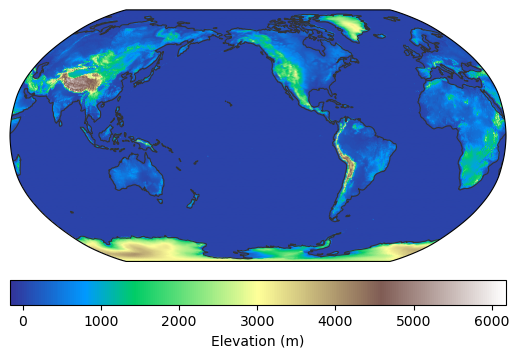

In [5]:
im = egh.healpix_show(ter, cmap='terrain')
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Elevation (m)')

<Figure size 640x480 with 0 Axes>

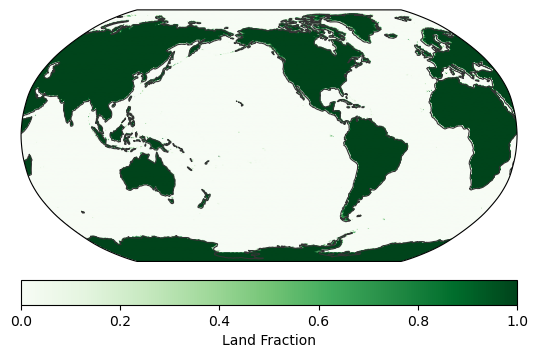

In [6]:
im = egh.healpix_show(landfrac, cmap='Greens', vmin=0, vmax=1)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Land Fraction')

## Read and combine all sources to a single DataSet

In [ ]:
drop_vars = []
# Read all files and combine them with a new dimension 'source'
ds = xr.open_mfdataset(list(filenames.values()), combine='nested', concat_dim='source', drop_variables=drop_vars).squeeze()
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())
# ds = ds.pipe(egh.attach_coords)
# Load lat/lon coordinates in memory
hp_lat = ds.lat.load()
hp_lon = ds.lon.load()
ds

<xarray.Dataset> Size: 29GB
Dimensions:                         (source: 6, time: 37, cell: 786432)
Coordinates:
  * time                            (time) datetime64[ns] 296B 2019-01-01 ......
  * cell                            (cell) int64 6MB 0 1 2 ... 786430 786431
    lat                             (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                             (cell) float64 6MB 45.0 45.18 ... 315.0
    crs                             int64 8B 0
  * source                          (source) <U3 72B 'obs' 'm1' ... 'm4' 'm5'
Data variables: (12/43)
    precipitation                   (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ntimes                          (source, time) float32 888B dask.array<chunksize=(1, 12), meta=np.ndarray>
    mcs_precipitation               (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_count                       (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_precipitation_count         (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ar_precipitation                (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ...                              ...
    st_precipitation                (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    st_count                        (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    nd_precipitation                (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    nd_count                        (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    dz_precipitation                (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    dz_count                        (source, time, cell) float32 698MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
Attributes:
    Title:                    Monthly precipitation statistics by co-occurren...
    contact:                  Zhe Feng, zhe.feng@pnnl.gov
    created_on:               Sun Sep 20 15:29:51 2026
    grid_type:                HEALPix
    zoom_level:               8
    time_interval:            6.0
    precipitation_threshold:  1.0
    precipitation_source:     tot_pr from Step 1 (make_mcs_swath_masks.py): w...
    category_assignment:      Priority-exclusive per grid cell and time step:...

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [8]:
ds.ntimes.sum(dim='time').values

array([4384., 1577., 1460., 1459., 1576., 1459.], dtype=float32)

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages

### Feature precipitation amount & fraction by season

In [9]:
# Get time interval from attributes
time_interval = float(ds.attrs['time_interval'])

# Group by season and compute seasonal means
# Group dataset by season
ds_season = ds.groupby('time.season')

# Calculate total hours for each season
ntimes_season = ds_season.map(lambda x: x.ntimes.sum(dim='time'))
nhours_season = ntimes_season * time_interval

# Sum seasonal precipitation amount [mm], divided by total hours to get mm/day
tot_pcp_season = ds_season.map(lambda x: 24. * x.precipitation.sum(dim='time')).compute() / nhours_season

# Original features
mcs_pcp_season = ds_season.map(lambda x: 24. * x.mcs_precipitation.sum(dim='time')).compute() / nhours_season
ar_pcp_season = ds_season.map(lambda x: 24. * x.ar_precipitation.sum(dim='time')).compute() / nhours_season
etc_pcp_season = ds_season.map(lambda x: 24. * x.etc_precipitation.sum(dim='time')).compute() / nhours_season
tc_pcp_season = ds_season.map(lambda x: 24. * x.tc_precipitation.sum(dim='time')).compute() / nhours_season

# Isolated features only
mcs_iso_pcp_season = ds_season.map(lambda x: 24. * x.mcs_iso_precipitation.sum(dim='time')).compute() / nhours_season
ar_iso_pcp_season = ds_season.map(lambda x: 24. * x.ar_iso_precipitation.sum(dim='time')).compute() / nhours_season
etc_iso_pcp_season = ds_season.map(lambda x: 24. * x.etc_iso_precipitation.sum(dim='time')).compute() / nhours_season

# Co-occurrence features
mcs_ar_pcp_season = ds_season.map(lambda x: 24. * x.mcs_ar_precipitation.sum(dim='time')).compute() / nhours_season
mcs_etc_pcp_season = ds_season.map(lambda x: 24. * x.mcs_etc_precipitation.sum(dim='time')).compute() / nhours_season
ar_etc_pcp_season = ds_season.map(lambda x: 24. * x.ar_etc_precipitation.sum(dim='time')).compute() / nhours_season
mcs_ar_etc_pcp_season = ds_season.map(lambda x: 24. * x.mcs_ar_etc_precipitation.sum(dim='time')).compute() / nhours_season

# Cloud types (not tracked)
dc_pcp_season = ds_season.map(lambda x: 24. * x.dc_precipitation.sum(dim='time')).compute() / nhours_season
nd_pcp_season = ds_season.map(lambda x: 24. * x.nd_precipitation.sum(dim='time')).compute() / nhours_season
st_pcp_season = ds_season.map(lambda x: 24. * x.st_precipitation.sum(dim='time')).compute() / nhours_season
dz_pcp_season = ds_season.map(lambda x: 24. * x.dz_precipitation.sum(dim='time')).compute() / nhours_season

# Calculate precipitation fractions
# Original features
mcs_pcpfrac_season = 100. * mcs_pcp_season / tot_pcp_season
tc_pcpfrac_season = 100. * tc_pcp_season / tot_pcp_season

# Isolated features only
mcs_iso_pcpfrac_season = 100. * mcs_iso_pcp_season / tot_pcp_season
ar_iso_pcpfrac_season = 100. * ar_iso_pcp_season / tot_pcp_season
tc_pcpfrac_season = 100. * tc_pcp_season / tot_pcp_season
etc_iso_pcpfrac_season = 100. * etc_iso_pcp_season / tot_pcp_season

# Co-occurrence features
mcs_ar_pcpfrac_season = 100. * mcs_ar_pcp_season / tot_pcp_season
mcs_etc_pcpfrac_season = 100. * mcs_etc_pcp_season / tot_pcp_season
ar_etc_pcpfrac_season = 100. * ar_etc_pcp_season / tot_pcp_season
mcs_ar_etc_pcpfrac_season = 100. * mcs_ar_etc_pcp_season / tot_pcp_season

# Cloud types (not tracked)
dc_pcpfrac_season = 100. * dc_pcp_season / tot_pcp_season
nd_pcpfrac_season = 100. * nd_pcp_season / tot_pcp_season
st_pcpfrac_season = 100. * st_pcp_season / tot_pcp_season
dz_pcpfrac_season = 100. * dz_pcp_season / tot_pcp_season

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages

<Figure size 640x480 with 0 Axes>

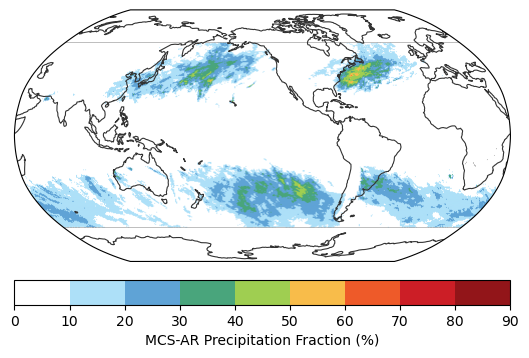

In [10]:
season = 'JJA'
# VAR = mcs_pcpfrac_season.sel(source='obs', season=season)
VAR = mcs_ar_pcpfrac_season.sel(source='obs', season=season)

colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 90.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(VAR, cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='MCS-AR Precipitation Fraction (%)')

### Feature frequency by season

In [11]:
# Sum feature mask counts (time steps) by season
# Original features
mcs_count_season = ds_season.map(lambda x: x.mcs_count.sum(dim='time')).compute()
ar_count_season = ds_season.map(lambda x: x.ar_count.sum(dim='time')).compute()
etc_count_season = ds_season.map(lambda x: x.etc_count.sum(dim='time')).compute()
tc_count_season = ds_season.map(lambda x: x.tc_count.sum(dim='time')).compute()

# Isolated features only
mcs_iso_count_season = ds_season.map(lambda x: x.mcs_iso_count.sum(dim='time')).compute()
ar_iso_count_season = ds_season.map(lambda x: x.ar_iso_count.sum(dim='time')).compute()
etc_iso_count_season = ds_season.map(lambda x: x.etc_iso_count.sum(dim='time')).compute()

# Co-occurrence features
mcs_ar_count_season = ds_season.map(lambda x: x.mcs_ar_count.sum(dim='time')).compute()
mcs_etc_count_season = ds_season.map(lambda x: x.mcs_etc_count.sum(dim='time')).compute()
ar_etc_count_season = ds_season.map(lambda x: x.ar_etc_count.sum(dim='time')).compute()
mcs_ar_etc_count_season = ds_season.map(lambda x: x.mcs_ar_etc_count.sum(dim='time')).compute()

# Cloud types (not tracked)
dc_count_season = ds_season.map(lambda x: x.dc_count.sum(dim='time')).compute()
nd_count_season = ds_season.map(lambda x: x.nd_count.sum(dim='time')).compute()
st_count_season = ds_season.map(lambda x: x.st_count.sum(dim='time')).compute()
dz_count_season = ds_season.map(lambda x: x.dz_count.sum(dim='time')).compute()

# Calculate feature mask frequencies (as percentages)
# Original features
mcs_freq_season = 100. * mcs_count_season / ntimes_season
ar_freq_season = 100. * ar_count_season / ntimes_season
etc_freq_season = 100. * etc_count_season / ntimes_season
tc_freq_season = 100. * tc_count_season / ntimes_season

# Isolated features only
mcs_iso_freq_season = 100. * mcs_iso_count_season / ntimes_season
ar_iso_freq_season = 100. * ar_iso_count_season / ntimes_season
etc_iso_freq_season = 100. * etc_iso_count_season / ntimes_season

# Co-occurrence features
mcs_ar_freq_season = 100. * mcs_ar_count_season / ntimes_season
mcs_etc_freq_season = 100. * mcs_etc_count_season / ntimes_season
ar_etc_freq_season = 100. * ar_etc_count_season / ntimes_season
mcs_ar_etc_freq_season = 100. * mcs_ar_etc_count_season / ntimes_season

# Cloud types (not tracked)
dc_freq_season = 100. * dc_count_season / ntimes_season
nd_freq_season = 100. * nd_count_season / ntimes_season
st_freq_season = 100. * st_count_season / ntimes_season
dz_freq_season = 100. * dz_count_season / ntimes_season

### Feature precipitation frequency by season

In [12]:
# Number of feature precipitation hours by season
# Original features
mcs_pcpcount_season = ds_season.map(lambda x: x.mcs_precipitation_count.sum(dim='time')).compute()
ar_pcpcount_season = ds_season.map(lambda x: x.ar_precipitation_count.sum(dim='time')).compute()
etc_pcpcount_season = ds_season.map(lambda x: x.etc_precipitation_count.sum(dim='time')).compute()
tc_pcpcount_season = ds_season.map(lambda x: x.tc_precipitation_count.sum(dim='time')).compute()

# Isolated features only
mcs_iso_pcpcount_season = ds_season.map(lambda x: x.mcs_iso_precipitation_count.sum(dim='time')).compute()
ar_iso_pcpcount_season = ds_season.map(lambda x: x.ar_iso_precipitation_count.sum(dim='time')).compute()
etc_iso_pcpcount_season = ds_season.map(lambda x: x.etc_iso_precipitation_count.sum(dim='time')).compute()

# Co-occurrence features
mcs_ar_pcpcount_season = ds_season.map(lambda x: x.mcs_ar_precipitation_count.sum(dim='time')).compute()
mcs_etc_pcpcount_season = ds_season.map(lambda x: x.mcs_etc_precipitation_count.sum(dim='time')).compute()
ar_etc_pcpcount_season = ds_season.map(lambda x: x.ar_etc_precipitation_count.sum(dim='time')).compute()
mcs_ar_etc_pcpcount_season = ds_season.map(lambda x: x.mcs_ar_etc_precipitation_count.sum(dim='time')).compute()

# Calculate feature precipitation frequencies (as percentages)
# Original features
mcs_pcpfreq_season = 100 * mcs_pcpcount_season / ntimes_season
ar_pcpfreq_season = 100 * ar_pcpcount_season / ntimes_season
etc_pcpfreq_season = 100 * etc_pcpcount_season / ntimes_season
tc_pcpfreq_season = 100 * tc_pcpcount_season / ntimes_season

# Isolated features only
mcs_iso_pcpfreq_season = 100 * mcs_iso_pcpcount_season / ntimes_season
ar_iso_pcpfreq_season = 100 * ar_iso_pcpcount_season / ntimes_season
etc_iso_pcpfreq_season = 100 * etc_iso_pcpcount_season / ntimes_season

# Co-occurrence features
mcs_ar_pcpfreq_season = 100 * mcs_ar_pcpcount_season / ntimes_season
mcs_etc_pcpfreq_season = 100 * mcs_etc_pcpcount_season / ntimes_season
ar_etc_pcpfreq_season = 100 * ar_etc_pcpcount_season / ntimes_season
mcs_ar_etc_pcpfreq_season = 100 * mcs_ar_etc_pcpcount_season / ntimes_season

<Figure size 640x480 with 0 Axes>

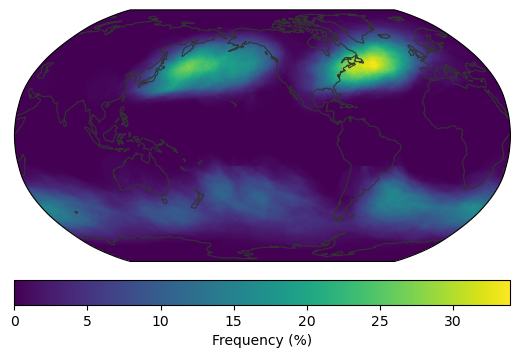

In [13]:
season = 'DJF'
# VAR = mcs_freq_season.sel(source='obs', season=season)
# VAR = etc_iso_freq_season.sel(source='obs', season=season)
# VAR = ar_iso_freq_season.sel(source='obs', season=season)
# VAR = mcs_ar_freq_season.sel(source='obs', season=season)
VAR = mcs_ar_etc_freq_season.sel(source='obs', season=season)

im = egh.healpix_show(VAR)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Frequency (%)')

### Precipitation amount and fraction by season (land vs. ocean)

<Figure size 640x480 with 0 Axes>

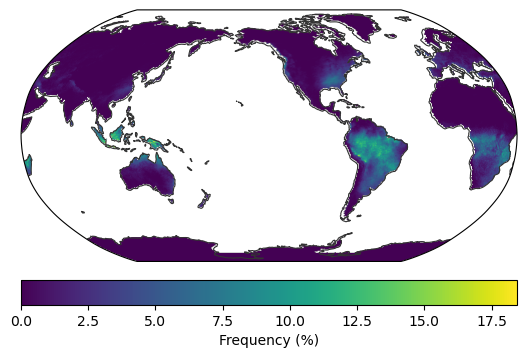

In [14]:
season = 'DJF'
VAR = mcs_pcpfreq_season.where(landfrac == 1).sel(season='DJF', source='obs')

im = egh.healpix_show(VAR)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Frequency (%)')

### Function to compute zonal mean

In [15]:
def compute_seasonal_zonal_mean(var_season, lat_var, lat_bins=None):
    """
    Compute zonal means for a seasonal variable using xarray's groupby_bins.
    
    This implementation is much faster than looping as it leverages xarray's
    vectorized operations and efficient groupby mechanism.
    
    Parameters
    ----------
    var_season : xarray.DataArray
        Seasonal variable with dimensions (season, cell) or (season, source, cell)
        where cell corresponds to HEALPix cells. The 'lat' coordinate should be
        associated with the 'cell' dimension.
    lat_var : xarray.DataArray
        Latitude values for each cell (1D array with dimension 'cell').
        Not used directly but kept for API compatibility.
    lat_bins : array-like, optional
        Latitude bin edges for grouping. If None, uses 1-degree bins from -90 to 90.
        
    Returns
    -------
    xarray.DataArray
        Zonal mean values with dimensions (season, latitude) if no source dimension,
        or (season, source, latitude) if source dimension exists
        
    Example
    -------
    >>> mcs_zonal = compute_seasonal_zonal_mean(mcs_pcp_season, ds.lat)
    >>> # Result shape: (season: 4, source: 6, latitude: 180) for 1-degree bins with sources
    >>> # or (season: 4, latitude: 180) for 1-degree bins without sources
    """
    
    # Default latitude bins: 1-degree resolution
    if lat_bins is None:
        lat_bins = np.arange(-90, 91, 1)
    
    # Get latitude centers from bin edges
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    
    # Use groupby_bins to efficiently group by latitude and compute means
    # Don't use labels parameter - we'll assign numeric coordinates afterward
    zonal_grouped = var_season.groupby_bins('lat', bins=lat_bins)
    
    # Compute the mean across cells in each latitude bin
    # This automatically preserves other dimensions (season, source if present)
    result = zonal_grouped.mean(dim='cell')
    
    # Rename the grouped dimension to 'latitude'
    result = result.rename({'lat_bins': 'latitude'})
    
    # Replace the interval index with numeric latitude centers
    # This makes it possible to use .sel(latitude=10, method='nearest')
    result = result.assign_coords(latitude=lat_centers)
    
    # Update attributes
    result.attrs['long_name'] = f'Zonal mean of {var_season.name if hasattr(var_season, "name") else "variable"}'
    if hasattr(var_season, 'attrs') and 'units' in var_season.attrs:
        result.attrs['units'] = var_season.attrs['units']
    
    return result

In [16]:
# # Demonstration: Compute zonal means for MCS precipitation
# # Using 2-degree latitude bins for faster computation
# lat_bins = np.arange(-60, 61, 1)

# # Compute zonal mean for MCS precipitation (handles multiple sources automatically)
# mcs_pcp_zonal = compute_seasonal_zonal_mean(mcs_pcp_season, ds.lat, lat_bins=lat_bins)

# print(f"Zonal mean shape: {mcs_pcp_zonal.shape}")
# print(f"Dimensions: {mcs_pcp_zonal.dims}")
# print(f"Seasons: {mcs_pcp_zonal.season.values}")
# if 'source' in mcs_pcp_zonal.dims:
#     print(f"Sources: {mcs_pcp_zonal.source.values}")
# print(f"Latitude range: {mcs_pcp_zonal.latitude.min().values:.1f} to {mcs_pcp_zonal.latitude.max().values:.1f}")

In [17]:
# Compute zonal means for all feature types and metrics
# Using 2-degree latitude bins for efficiency
lat_bins = np.arange(-60, 61, 2)

print("Computing zonal means for precipitation amounts...")
# Total precipitation
tot_pcp_zonal = compute_seasonal_zonal_mean(tot_pcp_season, ds.lat, lat_bins=lat_bins)

# Original features
mcs_pcp_zonal = compute_seasonal_zonal_mean(mcs_pcp_season, ds.lat, lat_bins=lat_bins)
ar_pcp_zonal = compute_seasonal_zonal_mean(ar_pcp_season, ds.lat, lat_bins=lat_bins)
etc_pcp_zonal = compute_seasonal_zonal_mean(etc_pcp_season, ds.lat, lat_bins=lat_bins)
tc_pcp_zonal = compute_seasonal_zonal_mean(tc_pcp_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_pcp_zonal = compute_seasonal_zonal_mean(mcs_iso_pcp_season, ds.lat, lat_bins=lat_bins)
ar_iso_pcp_zonal = compute_seasonal_zonal_mean(ar_iso_pcp_season, ds.lat, lat_bins=lat_bins)
etc_iso_pcp_zonal = compute_seasonal_zonal_mean(etc_iso_pcp_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_pcp_zonal = compute_seasonal_zonal_mean(mcs_ar_pcp_season, ds.lat, lat_bins=lat_bins)
mcs_etc_pcp_zonal = compute_seasonal_zonal_mean(mcs_etc_pcp_season, ds.lat, lat_bins=lat_bins)
ar_etc_pcp_zonal = compute_seasonal_zonal_mean(ar_etc_pcp_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_pcp_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_pcp_season, ds.lat, lat_bins=lat_bins)

# Cloud types
dc_pcp_zonal = compute_seasonal_zonal_mean(dc_pcp_season, ds.lat, lat_bins=lat_bins)
st_pcp_zonal = compute_seasonal_zonal_mean(st_pcp_season, ds.lat, lat_bins=lat_bins)
nd_pcp_zonal = compute_seasonal_zonal_mean(nd_pcp_season, ds.lat, lat_bins=lat_bins)
dz_pcp_zonal = compute_seasonal_zonal_mean(dz_pcp_season, ds.lat, lat_bins=lat_bins)

print("Computing zonal means for precipitation fractions...")
# Original features
mcs_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_pcpfrac_season, ds.lat, lat_bins=lat_bins)
tc_pcpfrac_zonal = compute_seasonal_zonal_mean(tc_pcpfrac_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_iso_pcpfrac_season, ds.lat, lat_bins=lat_bins)
ar_iso_pcpfrac_zonal = compute_seasonal_zonal_mean(ar_iso_pcpfrac_season, ds.lat, lat_bins=lat_bins)
etc_iso_pcpfrac_zonal = compute_seasonal_zonal_mean(etc_iso_pcpfrac_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_ar_pcpfrac_season, ds.lat, lat_bins=lat_bins)
mcs_etc_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_etc_pcpfrac_season, ds.lat, lat_bins=lat_bins)
ar_etc_pcpfrac_zonal = compute_seasonal_zonal_mean(ar_etc_pcpfrac_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfrac_season, ds.lat, lat_bins=lat_bins)

# Cloud types
dc_pcpfrac_zonal = compute_seasonal_zonal_mean(dc_pcpfrac_season, ds.lat, lat_bins=lat_bins)
st_pcpfrac_zonal = compute_seasonal_zonal_mean(st_pcpfrac_season, ds.lat, lat_bins=lat_bins)
nd_pcpfrac_zonal = compute_seasonal_zonal_mean(nd_pcpfrac_season, ds.lat, lat_bins=lat_bins)
dz_pcpfrac_zonal = compute_seasonal_zonal_mean(dz_pcpfrac_season, ds.lat, lat_bins=lat_bins)

print("Computing zonal means for feature frequencies...")
# Original features
mcs_freq_zonal = compute_seasonal_zonal_mean(mcs_freq_season, ds.lat, lat_bins=lat_bins)
ar_freq_zonal = compute_seasonal_zonal_mean(ar_freq_season, ds.lat, lat_bins=lat_bins)
etc_freq_zonal = compute_seasonal_zonal_mean(etc_freq_season, ds.lat, lat_bins=lat_bins)
tc_freq_zonal = compute_seasonal_zonal_mean(tc_freq_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_freq_zonal = compute_seasonal_zonal_mean(mcs_iso_freq_season, ds.lat, lat_bins=lat_bins)
ar_iso_freq_zonal = compute_seasonal_zonal_mean(ar_iso_freq_season, ds.lat, lat_bins=lat_bins)
etc_iso_freq_zonal = compute_seasonal_zonal_mean(etc_iso_freq_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_freq_zonal = compute_seasonal_zonal_mean(mcs_ar_freq_season, ds.lat, lat_bins=lat_bins)
mcs_etc_freq_zonal = compute_seasonal_zonal_mean(mcs_etc_freq_season, ds.lat, lat_bins=lat_bins)
ar_etc_freq_zonal = compute_seasonal_zonal_mean(ar_etc_freq_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_freq_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_freq_season, ds.lat, lat_bins=lat_bins)

# Cloud types
dc_freq_zonal = compute_seasonal_zonal_mean(dc_freq_season, ds.lat, lat_bins=lat_bins)
st_freq_zonal = compute_seasonal_zonal_mean(st_freq_season, ds.lat, lat_bins=lat_bins)
nd_freq_zonal = compute_seasonal_zonal_mean(nd_freq_season, ds.lat, lat_bins=lat_bins)
dz_freq_zonal = compute_seasonal_zonal_mean(dz_freq_season, ds.lat, lat_bins=lat_bins)

print("Computing zonal means for precipitation frequencies...")
# Original features
mcs_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_pcpfreq_season, ds.lat, lat_bins=lat_bins)
ar_pcpfreq_zonal = compute_seasonal_zonal_mean(ar_pcpfreq_season, ds.lat, lat_bins=lat_bins)
etc_pcpfreq_zonal = compute_seasonal_zonal_mean(etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)
tc_pcpfreq_zonal = compute_seasonal_zonal_mean(tc_pcpfreq_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_iso_pcpfreq_season, ds.lat, lat_bins=lat_bins)
ar_iso_pcpfreq_zonal = compute_seasonal_zonal_mean(ar_iso_pcpfreq_season, ds.lat, lat_bins=lat_bins)
etc_iso_pcpfreq_zonal = compute_seasonal_zonal_mean(etc_iso_pcpfreq_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_ar_pcpfreq_season, ds.lat, lat_bins=lat_bins)
mcs_etc_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)
ar_etc_pcpfreq_zonal = compute_seasonal_zonal_mean(ar_etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)

print("✅ All zonal means computed successfully!")
print(f"   Output shape example: {mcs_pcp_zonal.shape}")
print(f"   Dimensions: {mcs_pcp_zonal.dims}")

Computing zonal means for precipitation amounts...
Computing zonal means for precipitation fractions...
Computing zonal means for feature frequencies...
Computing zonal means for precipitation frequencies...
✅ All zonal means computed successfully!
   Output shape example: (4, 6, 60)
   Dimensions: ('season', 'source', 'latitude')


In [18]:
# Compute zonal means separately for land vs. ocean
# Land: landfrac > 0.95, Ocean: landfrac < 0.05

print("Computing zonal means for LAND (landfrac > 0.95)...")
print("=" * 60)

print("Computing precipitation amounts (land)...")
# Total precipitation - land
tot_pcp_zonal_land = compute_seasonal_zonal_mean(tot_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Original features - land
mcs_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_pcp_zonal_land = compute_seasonal_zonal_mean(ar_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_pcp_zonal_land = compute_seasonal_zonal_mean(etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_pcp_zonal_land = compute_seasonal_zonal_mean(tc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_iso_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_pcp_zonal_land = compute_seasonal_zonal_mean(ar_iso_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_pcp_zonal_land = compute_seasonal_zonal_mean(etc_iso_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_ar_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_pcp_zonal_land = compute_seasonal_zonal_mean(ar_etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Cloud types - land
dc_pcp_zonal_land = compute_seasonal_zonal_mean(dc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
st_pcp_zonal_land = compute_seasonal_zonal_mean(st_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
nd_pcp_zonal_land = compute_seasonal_zonal_mean(nd_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
dz_pcp_zonal_land = compute_seasonal_zonal_mean(dz_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("Computing precipitation fractions (land)...")
# Original features - land
mcs_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(tc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_iso_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfrac_zonal_land = compute_seasonal_zonal_mean(ar_iso_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfrac_zonal_land = compute_seasonal_zonal_mean(etc_iso_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_ar_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_etc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(ar_etc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Cloud types - land
dc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(dc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
st_pcpfrac_zonal_land = compute_seasonal_zonal_mean(st_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
nd_pcpfrac_zonal_land = compute_seasonal_zonal_mean(nd_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
dz_pcpfrac_zonal_land = compute_seasonal_zonal_mean(dz_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("Computing feature frequencies (land)...")
# Original features - land
mcs_freq_zonal_land = compute_seasonal_zonal_mean(mcs_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_freq_zonal_land = compute_seasonal_zonal_mean(ar_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_freq_zonal_land = compute_seasonal_zonal_mean(etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_freq_zonal_land = compute_seasonal_zonal_mean(tc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_freq_zonal_land = compute_seasonal_zonal_mean(mcs_iso_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_freq_zonal_land = compute_seasonal_zonal_mean(ar_iso_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_freq_zonal_land = compute_seasonal_zonal_mean(etc_iso_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_freq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_freq_zonal_land = compute_seasonal_zonal_mean(mcs_etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_freq_zonal_land = compute_seasonal_zonal_mean(ar_etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_freq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Cloud types - land
dc_freq_zonal_land = compute_seasonal_zonal_mean(dc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
st_freq_zonal_land = compute_seasonal_zonal_mean(st_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
nd_freq_zonal_land = compute_seasonal_zonal_mean(nd_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
dz_freq_zonal_land = compute_seasonal_zonal_mean(dz_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("Computing precipitation frequencies (land)...")
# Original features - land
mcs_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_pcpfreq_zonal_land = compute_seasonal_zonal_mean(ar_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(tc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_iso_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfreq_zonal_land = compute_seasonal_zonal_mean(ar_iso_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfreq_zonal_land = compute_seasonal_zonal_mean(etc_iso_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(ar_etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("\n" + "=" * 60)
print("Computing zonal means for OCEAN (landfrac < 0.05)...")
print("=" * 60)

print("Computing precipitation amounts (ocean)...")
# Total precipitation - ocean
tot_pcp_zonal_ocean = compute_seasonal_zonal_mean(tot_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Original features - ocean
mcs_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_pcp_zonal_ocean = compute_seasonal_zonal_mean(ar_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_pcp_zonal_ocean = compute_seasonal_zonal_mean(tc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_pcp_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_pcp_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Cloud types - ocean
dc_pcp_zonal_ocean = compute_seasonal_zonal_mean(dc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
st_pcp_zonal_ocean = compute_seasonal_zonal_mean(st_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
nd_pcp_zonal_ocean = compute_seasonal_zonal_mean(nd_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
dz_pcp_zonal_ocean = compute_seasonal_zonal_mean(dz_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("Computing precipitation fractions (ocean)...")
# Original features - ocean
mcs_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(tc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Cloud types - ocean
dc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(dc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
st_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(st_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
nd_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(nd_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
dz_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(dz_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("Computing feature frequencies (ocean)...")
# Original features - ocean
mcs_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_freq_zonal_ocean = compute_seasonal_zonal_mean(ar_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_freq_zonal_ocean = compute_seasonal_zonal_mean(etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_freq_zonal_ocean = compute_seasonal_zonal_mean(tc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_freq_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_freq_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_freq_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Cloud types - ocean
dc_freq_zonal_ocean = compute_seasonal_zonal_mean(dc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
st_freq_zonal_ocean = compute_seasonal_zonal_mean(st_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
nd_freq_zonal_ocean = compute_seasonal_zonal_mean(nd_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
dz_freq_zonal_ocean = compute_seasonal_zonal_mean(dz_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("Computing precipitation frequencies (ocean)...")
# Original features - ocean
mcs_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(ar_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(tc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("\n" + "=" * 60)
print("✅ All land and ocean zonal means computed successfully!")
print("=" * 60)
print(f"Land example shape: {mcs_pcp_zonal_land.shape}")
print(f"Ocean example shape: {mcs_pcp_zonal_ocean.shape}")
print(f"Dimensions: {mcs_pcp_zonal_land.dims}")

Computing zonal means for LAND (landfrac > 0.95)...
Computing precipitation amounts (land)...
Computing precipitation fractions (land)...
Computing feature frequencies (land)...
Computing precipitation frequencies (land)...

Computing zonal means for OCEAN (landfrac < 0.05)...
Computing precipitation amounts (ocean)...
Computing precipitation fractions (ocean)...
Computing feature frequencies (ocean)...
Computing precipitation frequencies (ocean)...

✅ All land and ocean zonal means computed successfully!
Land example shape: (4, 6, 60)
Ocean example shape: (4, 6, 60)
Dimensions: ('season', 'source', 'latitude')


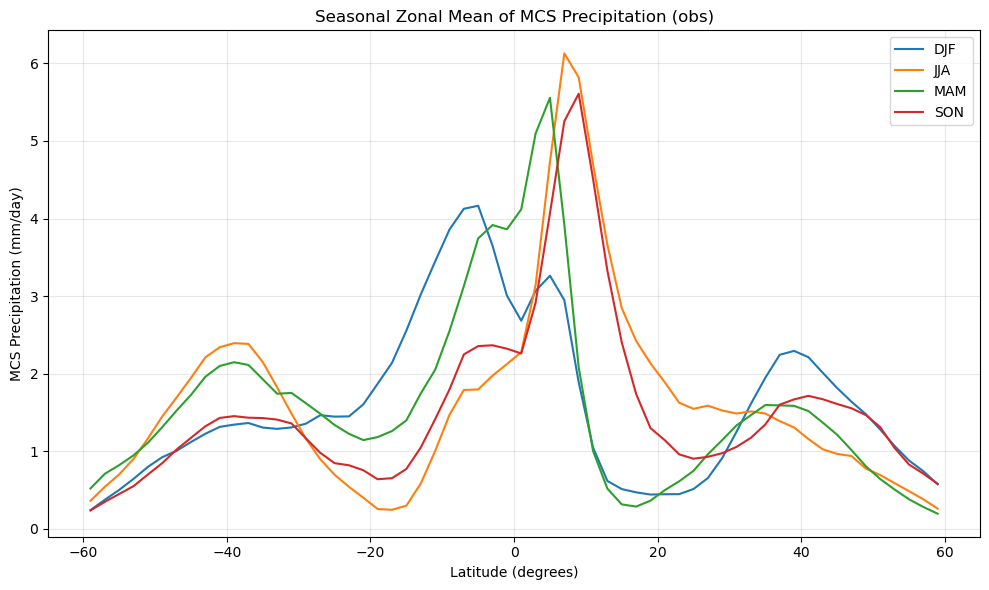

In [19]:
# Example 1: Plot zonal mean for all seasons (one source)
fig, ax = plt.subplots(figsize=(10, 6))
source_to_plot = 'obs'  # or 'm1', 'm2', etc.
for season in mcs_pcp_zonal.season.values:
    if 'source' in mcs_pcp_zonal.dims:
        mcs_pcp_zonal.sel(season=season, source=source_to_plot).plot(ax=ax, label=season)
    else:
        mcs_pcp_zonal.sel(season=season).plot(ax=ax, label=season)

ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('MCS Precipitation (mm/day)')
ax.set_title(f'Seasonal Zonal Mean of MCS Precipitation ({source_to_plot})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

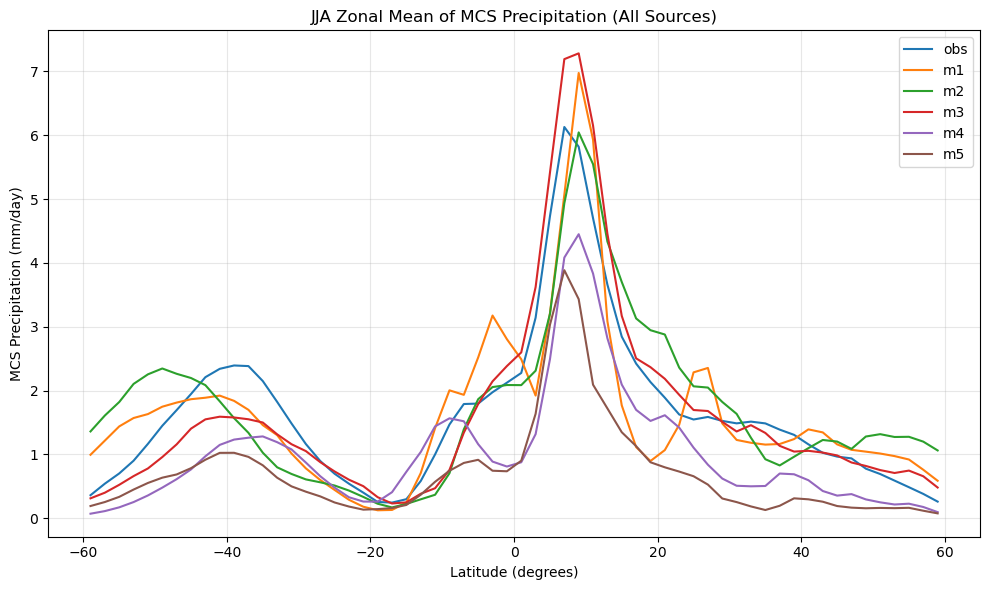


JJA 'obs' zonal mean at 10°N: 4.70 mm/day


In [20]:
# Example 2: Compare all sources for one season
if 'source' in mcs_pcp_zonal.dims:
    fig, ax = plt.subplots(figsize=(10, 6))
    season_to_plot = 'JJA'
    for source in mcs_pcp_zonal.source.values:
        mcs_pcp_zonal.sel(season=season_to_plot, source=source).plot(ax=ax, label=source)
    
    ax.set_xlabel('Latitude (degrees)')
    ax.set_ylabel('MCS Precipitation (mm/day)')
    ax.set_title(f'{season_to_plot} Zonal Mean of MCS Precipitation (All Sources)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example 3: Access specific values
if 'source' in mcs_pcp_zonal.dims:
    print(f"\nJJA 'obs' zonal mean at 10°N: {mcs_pcp_zonal.sel(season='JJA', source='obs').sel(latitude=10, method='nearest').values:.2f} mm/day")
else:
    print(f"\nJJA zonal mean at 10°N: {mcs_pcp_zonal.sel(season='JJA').sel(latitude=10, method='nearest').values:.2f} mm/day")

## Function to plot zonal mean

In [21]:
# Define color dictionary for sources
color_dict = {
    'obs': 'k', 
    'm1': 'dodgerblue', 
    'm2': 'deeppink', 
    'm3': 'green', 
    'm4': 'lime',
    'm5': 'darkorange',
}

In [22]:
def plot_two_zonal_mean_grids(left_data_list, right_data_list, color_dict,
                               left_panel_titles=None, right_panel_titles=None,
                               left_ylims=None, right_ylims=None,
                               xlabel='Latitude (°)', left_ylabel='Value',
                               right_ylabel='Value', left_title=None, right_title=None,
                               figsize=None, legend_loc='best', figname=None, dpi=200,
                               obs_linewidth=2.5, model_linewidth=1.5,
                               fontsize_title=12, fontsize_label=11,
                               fontsize_legend=9, fontsize_group_title=14,
                               sharex=True, sharey=False, legend_panels='all',
                               lat_lines=None, w_space=0.25, inner_wspace=0.20,
                               hspace=0.25, divider_linewidth=4,
                               divider_color='black'):
    """Plot two side-by-side M x N grids of zonal-mean profiles.

    The two groups are defined by an outer GridSpec. Each group is then split
    into its M x N panels with GridSpecFromSubplotSpec. The vertical divider
    is centered in the outer-grid gap and spans exactly from the top axes of
    the first row to the bottom axes of the last row.

    Parameters
    ----------
    left_data_list, right_data_list : list of lists of xarray.DataArray
        Matching M x N grids. Each DataArray must have source and latitude
        dimensions.
    color_dict : dict
        Mapping from source coordinate values to line colors.
    left_panel_titles, right_panel_titles : list of lists of str, optional
        Panel titles matching the corresponding data grid.
    left_ylims, right_ylims : tuple or M x N list, optional
        Y limits for each group. A single (ymin, ymax) tuple is applied to
        every panel in that group.
    w_space : float, optional
        Width space between the left and right groups in the outer GridSpec.
    inner_wspace, hspace : float, optional
        Width and height spacing within each group.
    divider_linewidth, divider_color : optional
        Appearance of the vertical line separating the groups.

    Returns
    -------
    fig, axes_left, axes_right
        Matplotlib Figure and the two M x N arrays of Axes.
    """
    def validate_grid(data_grid, grid_name):
        nrows = len(data_grid)
        if nrows == 0:
            raise ValueError(f'{grid_name} must contain at least one row')
        ncols = len(data_grid[0])
        if ncols == 0 or not all(len(row) == ncols for row in data_grid):
            raise ValueError(f'All rows in {grid_name} must have the same nonzero length')
        return nrows, ncols

    nrows, ncols = validate_grid(left_data_list, 'left_data_list')
    right_shape = validate_grid(right_data_list, 'right_data_list')
    if right_shape != (nrows, ncols):
        raise ValueError('left_data_list and right_data_list must have the same M x N shape')

    def prepare_titles(titles, group_name):
        if titles is None:
            return [[f'{group_name} panel ({i},{j})' for j in range(ncols)]
                    for i in range(nrows)]
        if len(titles) != nrows or not all(len(row) == ncols for row in titles):
            raise ValueError(f'{group_name}_panel_titles must match the data grid shape')
        return titles

    def prepare_ylims(group_ylims, group_name):
        if group_ylims is None:
            return [[None for _ in range(ncols)] for _ in range(nrows)]
        if (isinstance(group_ylims, tuple) and len(group_ylims) == 2 and
                all(np.isscalar(value) for value in group_ylims)):
            return [[group_ylims for _ in range(ncols)] for _ in range(nrows)]
        if (len(group_ylims) != nrows or
                not all(len(row) == ncols for row in group_ylims)):
            raise ValueError(f'{group_name}_ylims must be a tuple or match the data grid shape')
        return group_ylims

    left_panel_titles = prepare_titles(left_panel_titles, 'Left')
    right_panel_titles = prepare_titles(right_panel_titles, 'Right')
    left_ylims = prepare_ylims(left_ylims, 'left')
    right_ylims = prepare_ylims(right_ylims, 'right')

    if figsize is None:
        figsize = (10 * ncols, 3 * nrows)

    fig = plt.figure(figsize=figsize)
    outer_gs = gridspec.GridSpec(1, 2, figure=fig, wspace=w_space)
    group_gs = [
        gridspec.GridSpecFromSubplotSpec(
            nrows, ncols, subplot_spec=outer_gs[group],
            wspace=inner_wspace, hspace=hspace,
        )
        for group in range(2)
    ]
    axes_groups = [np.empty((nrows, ncols), dtype=object) for _ in range(2)]

    def should_have_legend(i, j):
        if legend_panels == 'all':
            return True
        if legend_panels == 'first':
            return i == 0 and j == 0
        if legend_panels == 'first_row':
            return i == 0
        if legend_panels == 'first_col':
            return j == 0
        if isinstance(legend_panels, list):
            return (i, j) in legend_panels
        return False

    groups = [
        (left_data_list, left_panel_titles, left_ylims, left_ylabel),
        (right_data_list, right_panel_titles, right_ylims, right_ylabel),
    ]
    shared_x_axis = None
    for group_index, (data_grid, titles, group_ylims, ylabel) in enumerate(groups):
        shared_y_axis = None
        for i in range(nrows):
            for j in range(ncols):
                subplot_kwargs = {}
                if sharex and shared_x_axis is not None:
                    subplot_kwargs['sharex'] = shared_x_axis
                if sharey and shared_y_axis is not None:
                    subplot_kwargs['sharey'] = shared_y_axis
                ax = fig.add_subplot(group_gs[group_index][i, j], **subplot_kwargs)
                axes_groups[group_index][i, j] = ax
                if shared_x_axis is None:
                    shared_x_axis = ax
                if shared_y_axis is None:
                    shared_y_axis = ax

                data = data_grid[i][j]
                for source in data.source.values:
                    linewidth = obs_linewidth if source == 'obs' else model_linewidth
                    ax.plot(
                        data.latitude.values, data.sel(source=source).values,
                        color=color_dict.get(source, 'gray'), linewidth=linewidth,
                        label=name_map_plot.get(source, source),
                    )

                ax.set_title(titles[i][j], fontsize=fontsize_title,
                             fontweight='bold', loc='left')
                ax.tick_params(axis='both', labelsize=fontsize_label)
                ax.grid(True, alpha=0.7, linestyle=':')
                if group_ylims[i][j] is not None:
                    ax.set_ylim(group_ylims[i][j])
                if lat_lines is not None:
                    lines = [lat_lines] if np.isscalar(lat_lines) else lat_lines
                    for latitude in lines:
                        ax.axvline(latitude, color='black', linestyle='--', linewidth=1.5)
                if j == 0:
                    ax.set_ylabel(ylabel, fontsize=fontsize_label)
                if i == nrows - 1:
                    ax.set_xlabel(xlabel, fontsize=fontsize_label)
                elif sharex:
                    ax.tick_params(axis='x', labelbottom=False)
                if should_have_legend(i, j):
                    ax.legend(loc=legend_loc, framealpha=0.9, fontsize=fontsize_legend)

    axes_left, axes_right = axes_groups
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.06, top=0.92)
    fig.canvas.draw()

    # Group titles are centered over the actual axes in each nested grid.
    for title, group_axes in zip((left_title, right_title), axes_groups):
        if title is not None:
            x_center = (group_axes[0, 0].get_position().x0 +
                        group_axes[0, -1].get_position().x1) / 2
            y_title = max(ax.get_position().y1 for ax in group_axes[0, :]) + 0.025
            fig.text(x_center, y_title, title, ha='center', va='bottom',
                     fontsize=fontsize_group_title, fontweight='bold')

    # Center the divider in the inter-group gap and match the grid's vertical span.
    left_edge = max(ax.get_position().x1 for ax in axes_left[:, -1])
    right_edge = min(ax.get_position().x0 for ax in axes_right[:, 0])
    x_divider = (left_edge + right_edge) / 2
    y_top = max(ax.get_position().y1 for ax in
                list(axes_left[0, :]) + list(axes_right[0, :]))
    y_bottom = min(ax.get_position().y0 for ax in
                   list(axes_left[-1, :]) + list(axes_right[-1, :]))
    divider = mpl.lines.Line2D(
        [x_divider, x_divider], [y_bottom, y_top],
        transform=fig.transFigure, color=divider_color,
        linewidth=divider_linewidth, clip_on=False, zorder=10,
    )
    fig.add_artist(divider)

    if figname is not None:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Figure saved: {figname}')

    return fig, axes_left, axes_right


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/ZonalMean_MCS_rain_rainfrac_4season_ocean_vs_land.png


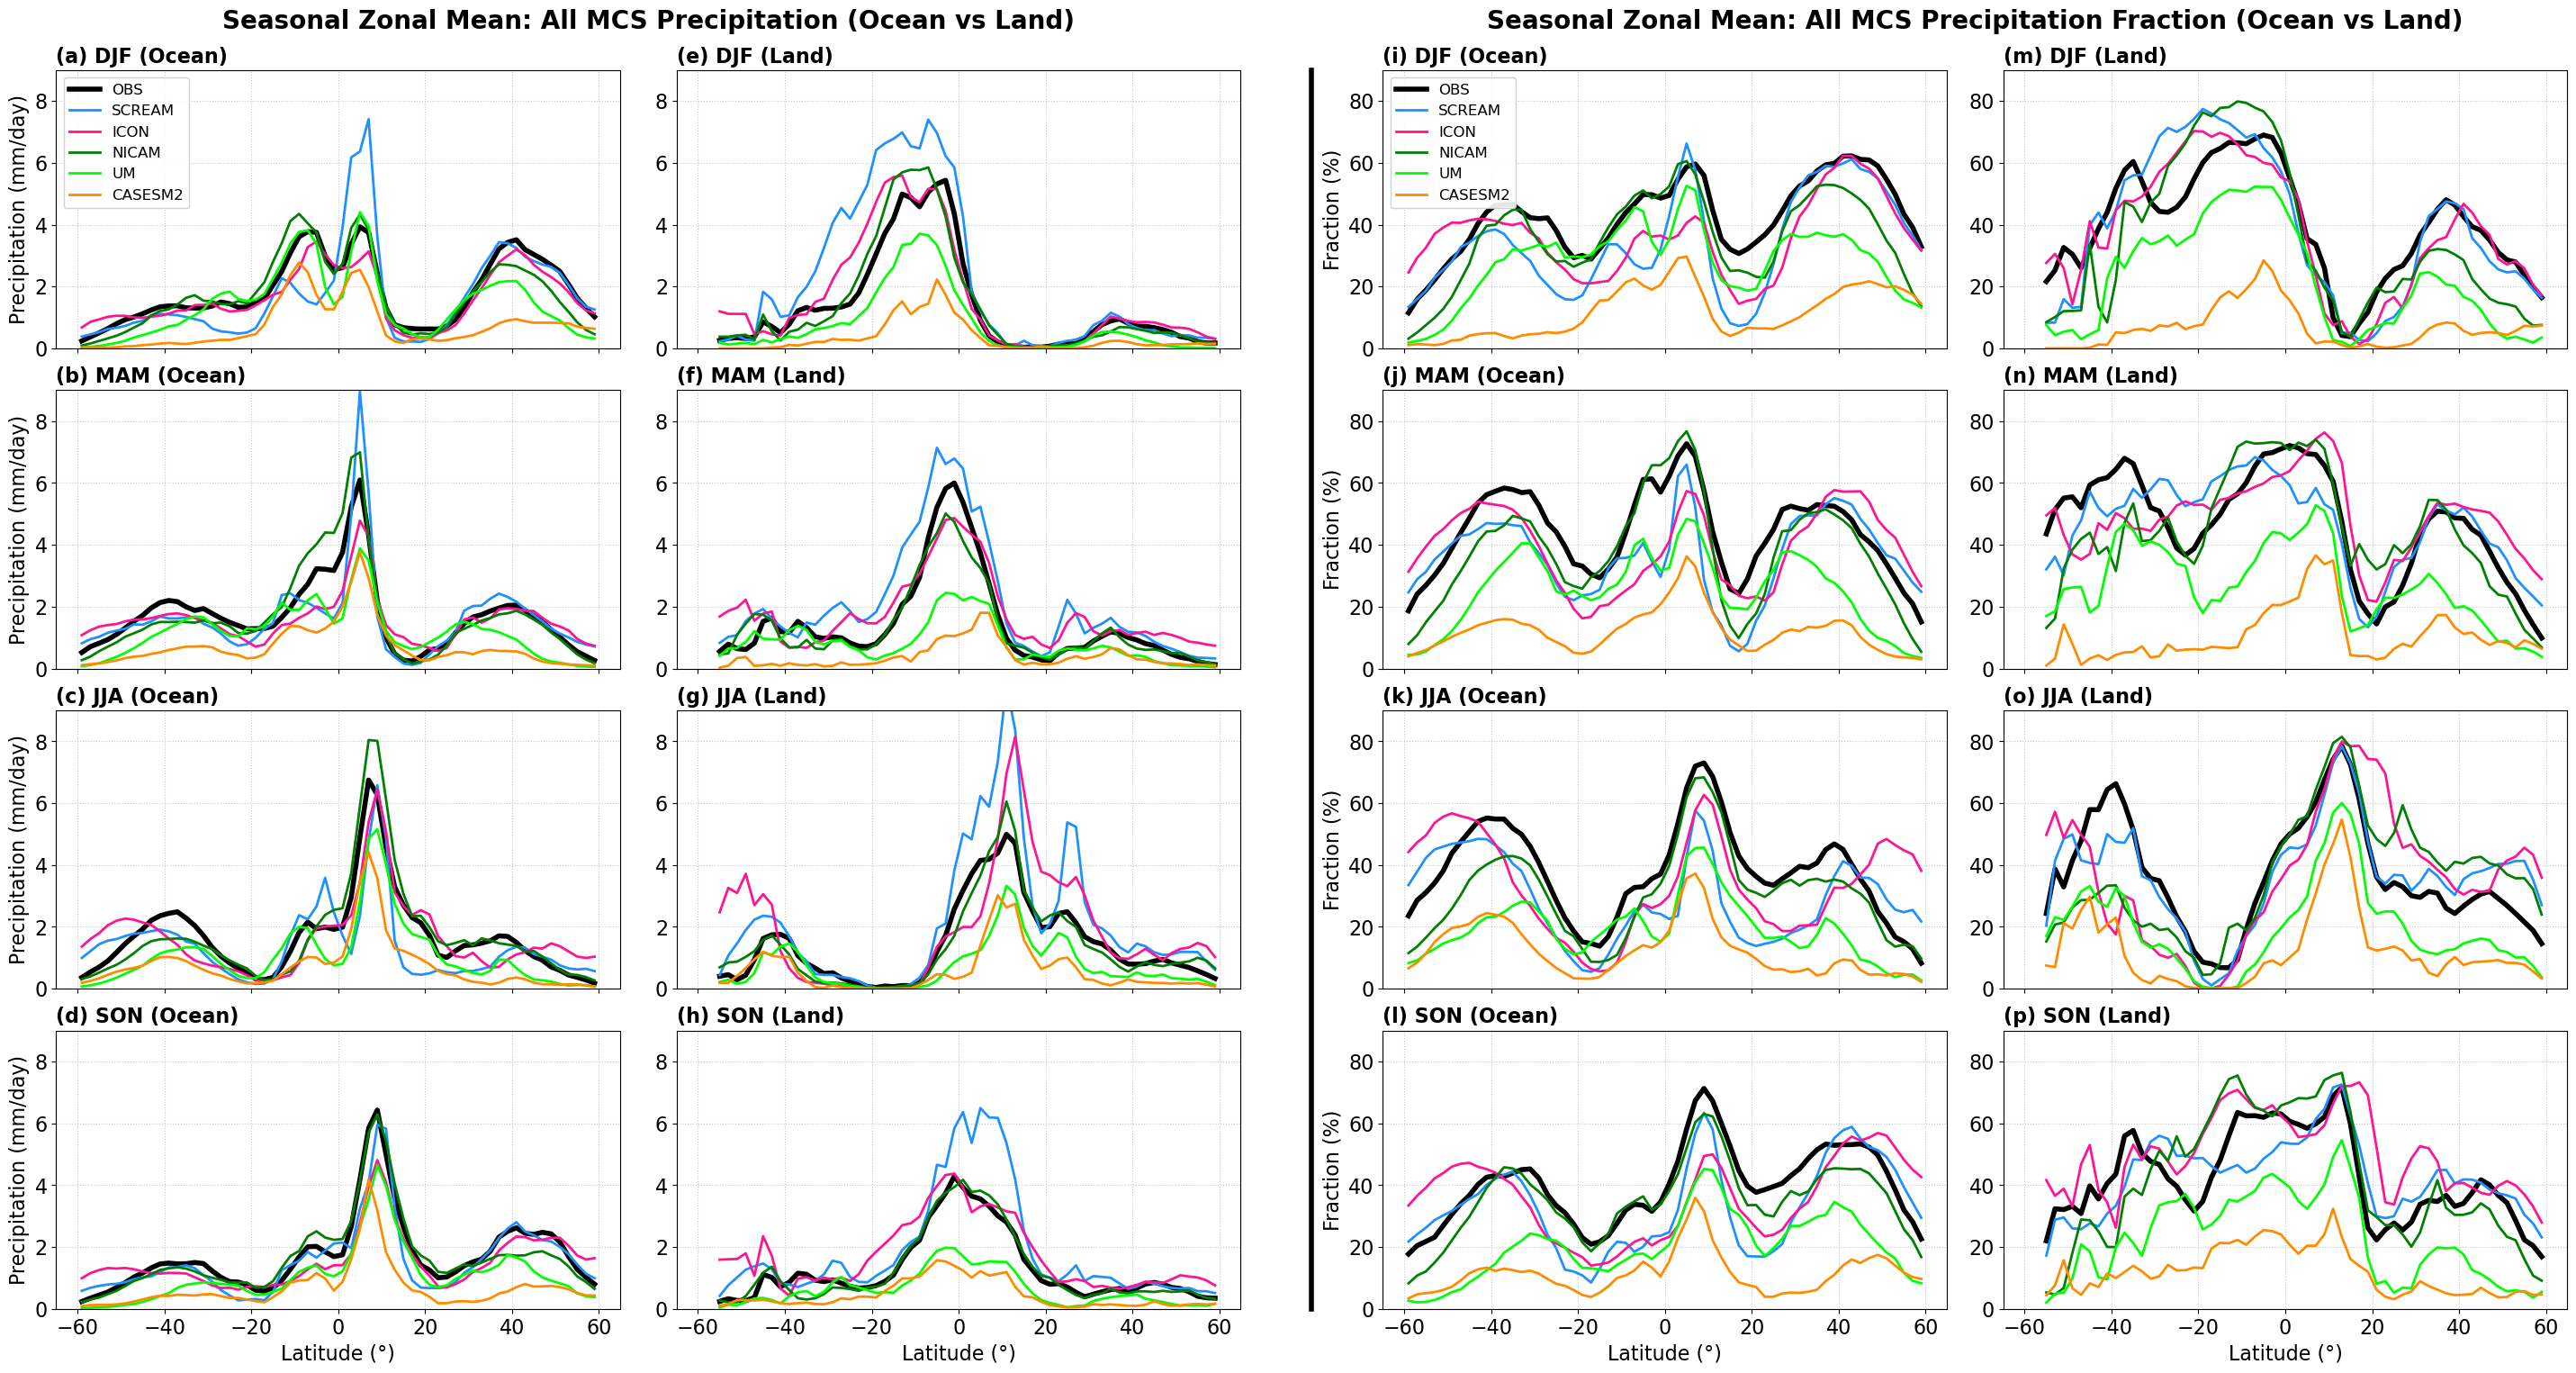

In [23]:
# Plot All MCS precipitation and precipitation fraction side by side
left_data_list = [
    [mcs_pcp_zonal_ocean.sel(season='DJF'), mcs_pcp_zonal_land.sel(season='DJF')],
    [mcs_pcp_zonal_ocean.sel(season='MAM'), mcs_pcp_zonal_land.sel(season='MAM')],
    [mcs_pcp_zonal_ocean.sel(season='JJA'), mcs_pcp_zonal_land.sel(season='JJA')],
    [mcs_pcp_zonal_ocean.sel(season='SON'), mcs_pcp_zonal_land.sel(season='SON')],
]
right_data_list = [
    [mcs_pcpfrac_zonal_ocean.sel(season='DJF'), mcs_pcpfrac_zonal_land.sel(season='DJF')],
    [mcs_pcpfrac_zonal_ocean.sel(season='MAM'), mcs_pcpfrac_zonal_land.sel(season='MAM')],
    [mcs_pcpfrac_zonal_ocean.sel(season='JJA'), mcs_pcpfrac_zonal_land.sel(season='JJA')],
    [mcs_pcpfrac_zonal_ocean.sel(season='SON'), mcs_pcpfrac_zonal_land.sel(season='SON')],
]
left_panel_titles = [
    ['(a) DJF (Ocean)', '(e) DJF (Land)'],
    ['(b) MAM (Ocean)', '(f) MAM (Land)'],
    ['(c) JJA (Ocean)', '(g) JJA (Land)'],
    ['(d) SON (Ocean)', '(h) SON (Land)'],
]
right_panel_titles = [
    ['(i) DJF (Ocean)', '(m) DJF (Land)'],
    ['(j) MAM (Ocean)', '(n) MAM (Land)'],
    ['(k) JJA (Ocean)', '(o) JJA (Land)'],
    ['(l) SON (Ocean)', '(p) SON (Land)'],
]
left_title = 'Seasonal Zonal Mean: All MCS Precipitation (Ocean vs Land)'
right_title = 'Seasonal Zonal Mean: All MCS Precipitation Fraction (Ocean vs Land)'
figname = f'{figdir}ZonalMean_MCS_rain_rainfrac_4season_ocean_vs_land.png'

fig, axes_left, axes_right = plot_two_zonal_mean_grids(
    left_data_list, right_data_list, color_dict,
    left_panel_titles=left_panel_titles, right_panel_titles=right_panel_titles,
    left_ylims=(0, 9), right_ylims=(0, 90), xlabel='Latitude (°)',
    left_ylabel='Precipitation (mm/day)', right_ylabel='Fraction (%)',
    left_title=left_title, right_title=right_title,
    figsize=(30, 16), figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=16, fontsize_label=16, fontsize_legend=12,
    fontsize_group_title=20, legend_panels='first', legend_loc='upper left',
    w_space=0.12, inner_wspace=0.1, hspace=0.15,
    divider_linewidth=4, divider_color='black',
)


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/ZonalMean_MCS-iso_rain_rainfrac_4season_ocean_vs_land.png


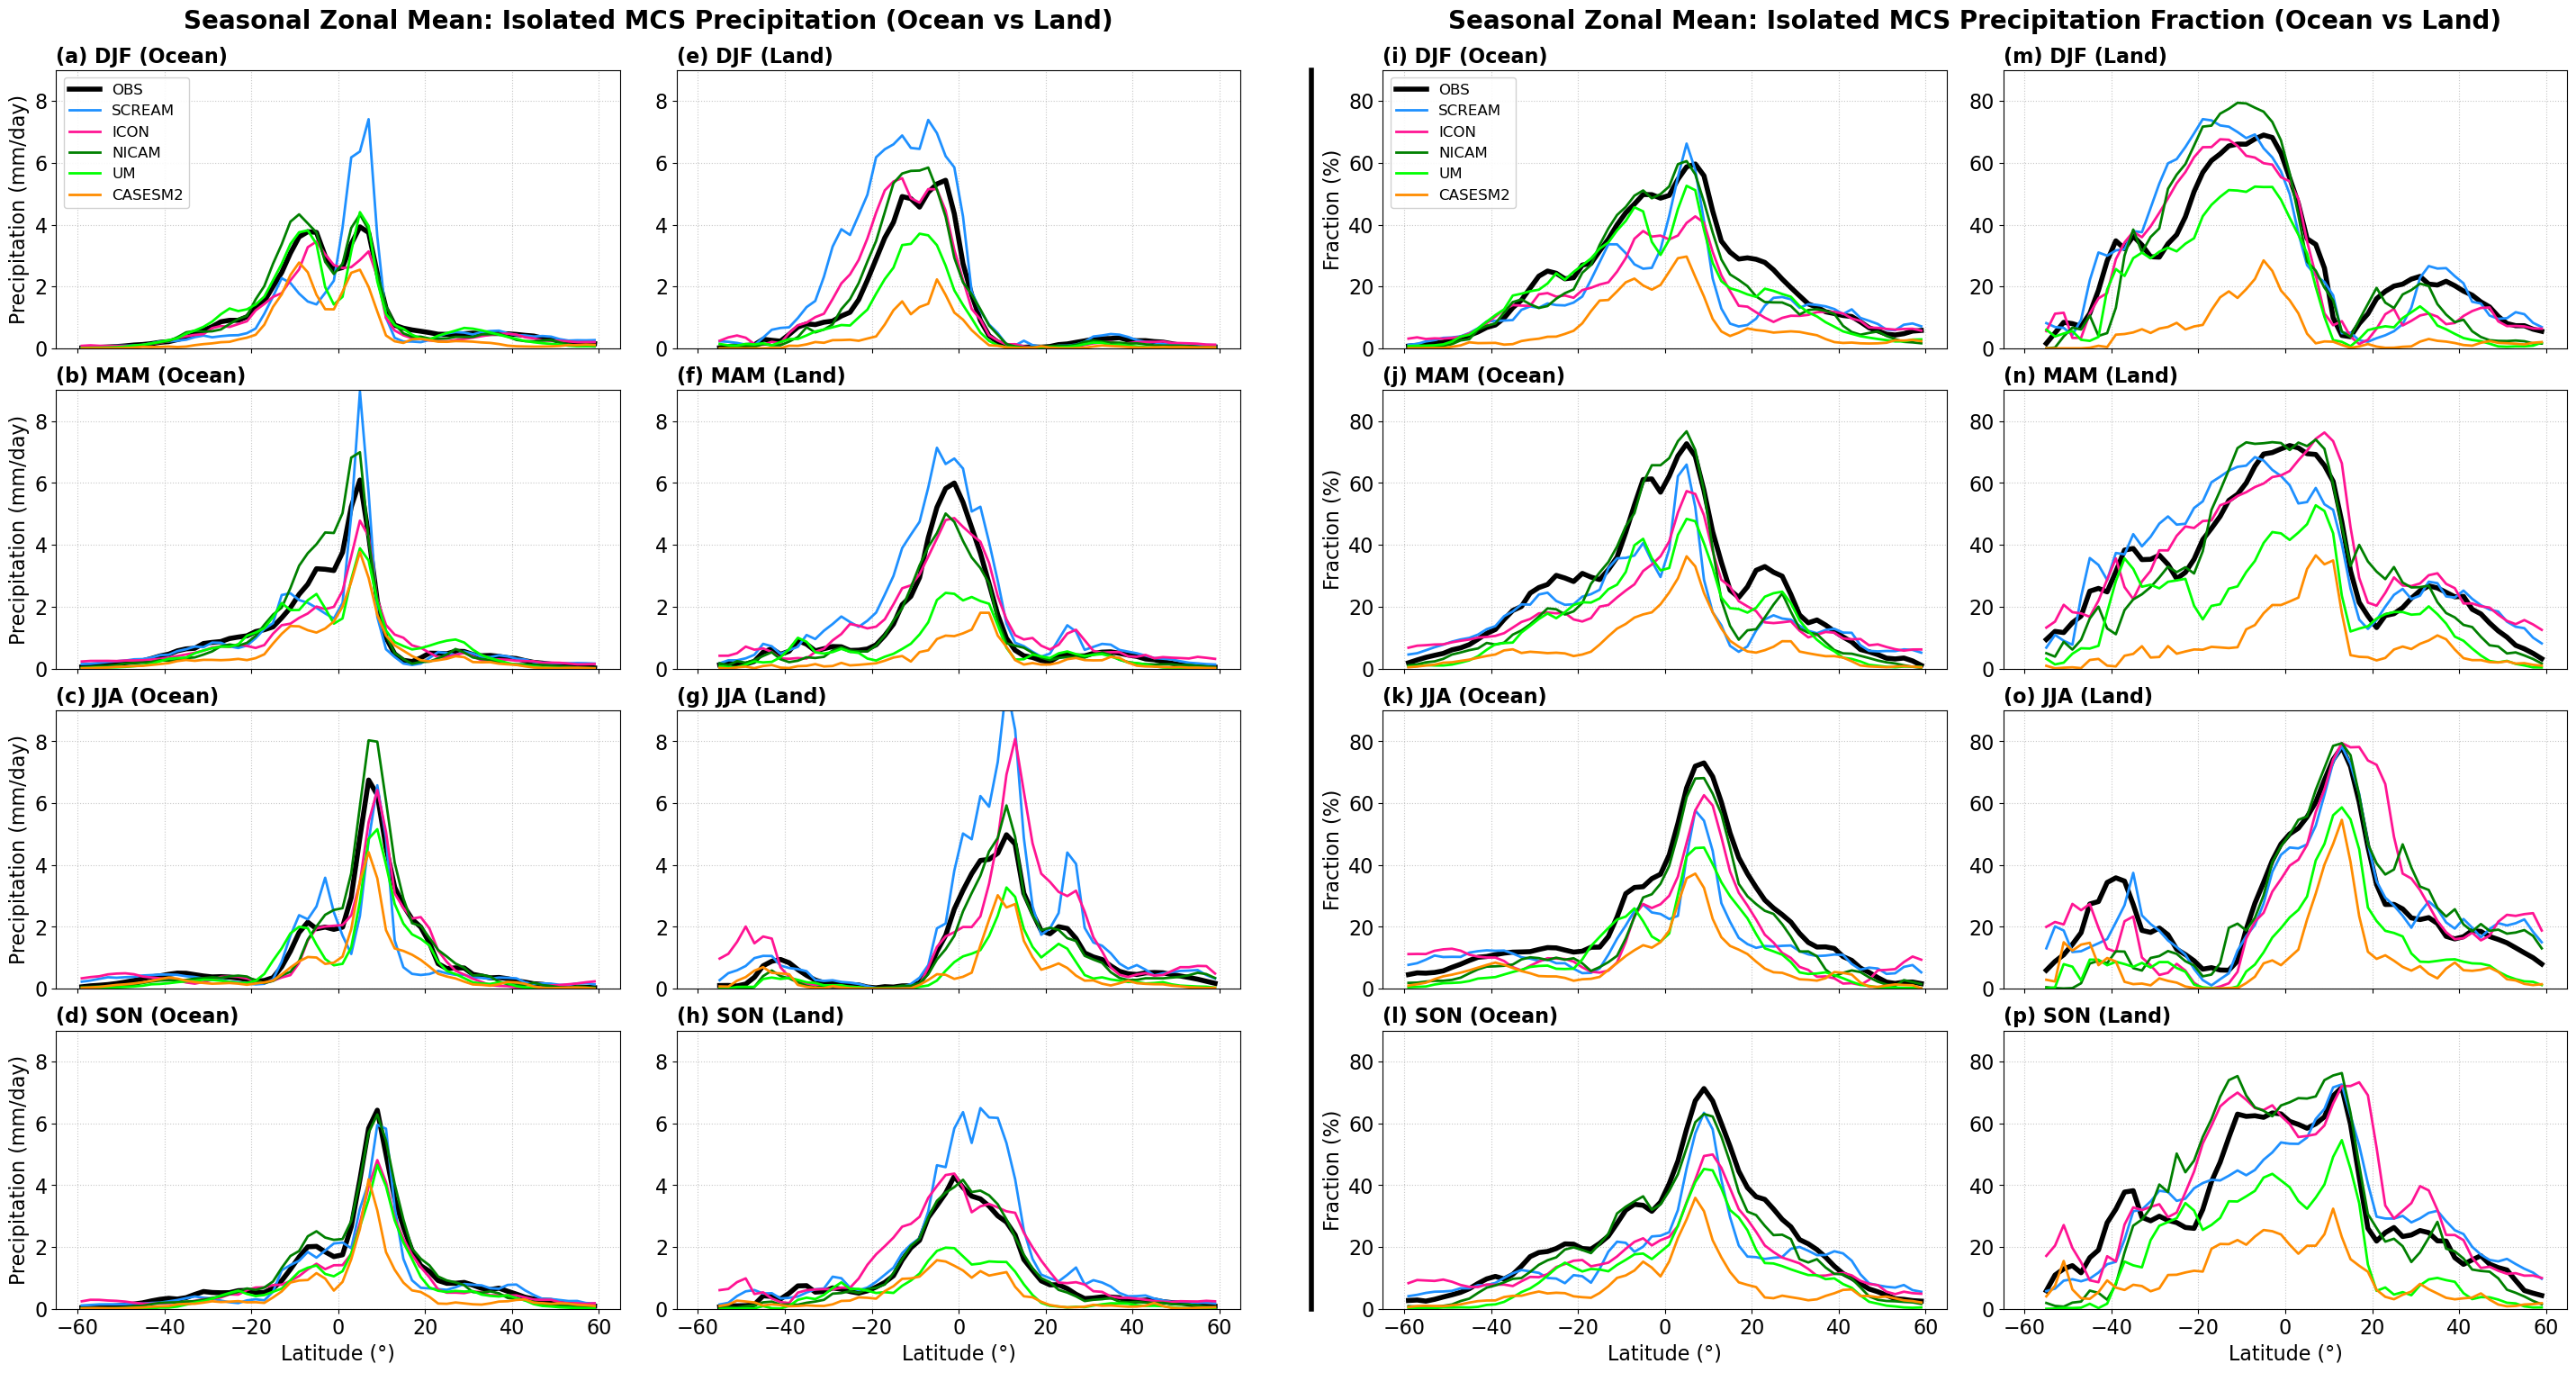

In [24]:
# Plot All MCS precipitation and precipitation fraction side by side
left_data_list = [
    [mcs_iso_pcp_zonal_ocean.sel(season='DJF'), mcs_iso_pcp_zonal_land.sel(season='DJF')],
    [mcs_iso_pcp_zonal_ocean.sel(season='MAM'), mcs_iso_pcp_zonal_land.sel(season='MAM')],
    [mcs_iso_pcp_zonal_ocean.sel(season='JJA'), mcs_iso_pcp_zonal_land.sel(season='JJA')],
    [mcs_iso_pcp_zonal_ocean.sel(season='SON'), mcs_iso_pcp_zonal_land.sel(season='SON')],
]
right_data_list = [
    [mcs_iso_pcpfrac_zonal_ocean.sel(season='DJF'), mcs_iso_pcpfrac_zonal_land.sel(season='DJF')],
    [mcs_iso_pcpfrac_zonal_ocean.sel(season='MAM'), mcs_iso_pcpfrac_zonal_land.sel(season='MAM')],
    [mcs_iso_pcpfrac_zonal_ocean.sel(season='JJA'), mcs_iso_pcpfrac_zonal_land.sel(season='JJA')],
    [mcs_iso_pcpfrac_zonal_ocean.sel(season='SON'), mcs_iso_pcpfrac_zonal_land.sel(season='SON')],
]
left_panel_titles = [
    ['(a) DJF (Ocean)', '(e) DJF (Land)'],
    ['(b) MAM (Ocean)', '(f) MAM (Land)'],
    ['(c) JJA (Ocean)', '(g) JJA (Land)'],
    ['(d) SON (Ocean)', '(h) SON (Land)'],
]
right_panel_titles = [
    ['(i) DJF (Ocean)', '(m) DJF (Land)'],
    ['(j) MAM (Ocean)', '(n) MAM (Land)'],
    ['(k) JJA (Ocean)', '(o) JJA (Land)'],
    ['(l) SON (Ocean)', '(p) SON (Land)'],
]
left_title = 'Seasonal Zonal Mean: Isolated MCS Precipitation (Ocean vs Land)'
right_title = 'Seasonal Zonal Mean: Isolated MCS Precipitation Fraction (Ocean vs Land)'
figname = f'{figdir}ZonalMean_MCS-iso_rain_rainfrac_4season_ocean_vs_land.png'

fig, axes_left, axes_right = plot_two_zonal_mean_grids(
    left_data_list, right_data_list, color_dict,
    left_panel_titles=left_panel_titles, right_panel_titles=right_panel_titles,
    left_ylims=(0, 9), right_ylims=(0, 90), xlabel='Latitude (°)',
    left_ylabel='Precipitation (mm/day)', right_ylabel='Fraction (%)',
    left_title=left_title, right_title=right_title,
    figsize=(30, 16), figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=16, fontsize_label=16, fontsize_legend=12,
    fontsize_group_title=20, legend_panels='first', legend_loc='upper left',
    w_space=0.12, inner_wspace=0.1, hspace=0.15,
    divider_linewidth=4, divider_color='black',
)

### Function to plot a single group

In [25]:
def plot_zonal_mean_grid(data_list, color_dict, panel_titles=None, 
                          ylims=None, xlabel='Latitude (°)', ylabel='Value',
                          suptitle=None, figsize=None, legend_loc='best',
                          figname=None, dpi=200,
                          obs_linewidth=2.5, model_linewidth=1.5,
                          fontsize_title=12, fontsize_label=11, 
                          fontsize_legend=9, fontsize_suptitle=14,
                          sharex=True, sharey=False, legend_panels='all',
                          lat_lines=None,
                          ):
    """
    Plot zonal means for multiple sources in M x N grid of panels.
    
    Each panel shows multiple sources as line plots, with 'obs' line thicker than model lines.
    
    Parameters
    ----------
    data_list : list of lists of xarray.DataArray
        2D list (M rows x N columns) of datasets to plot. 
        Structure: [[row0_col0, row0_col1, ...], [row1_col0, row1_col1, ...], ...]
        Each element should have dimensions (source, latitude).
        Example for 2x2 grid:
            [[data_DJF_var1, data_DJF_var2],
             [data_JJA_var1, data_JJA_var2]]
    color_dict : dict
        Dictionary mapping source names to colors. Keys should match 'source' coordinate.
        Example: {'obs': 'black', 'm1': 'red', 'm2': 'blue', ...}
    panel_titles : list of lists of str, optional
        Title for each panel matching the structure of data_list.
        Example for 2x2 grid: [['(a) DJF Var1', '(b) DJF Var2'], 
                                ['(c) JJA Var1', '(d) JJA Var2']]
        If None, generates default titles like 'Panel (0,0)', 'Panel (0,1)', etc.
    ylims : tuple or list, optional
        Y-axis limits. Can be:
        - Single tuple (ymin, ymax) applied to all panels
        - 2D list matching data_list structure for individual control per panel
        - None for automatic limits
    xlabel : str, optional
        X-axis label (default: 'Latitude (°)')
    ylabel : str, optional
        Y-axis label (default: 'Value')
    suptitle : str, optional
        Figure super title (default: None)
    figsize : tuple, optional
        Figure size (width, height). If None, auto-calculated based on grid size.
    legend_loc : str, optional (default: 'best')
        Location of the legend
    figname : str, optional
        Figure name to save.
    dpi : int, optional (default: 200)
        DPI for saving the figure.
    obs_linewidth : float, optional
        Line width for 'obs' source (default: 2.5)
    model_linewidth : float, optional
        Line width for model sources (default: 1.5)
    fontsize_title : int, optional
        Font size for panel titles (default: 12)
    fontsize_label : int, optional
        Font size for axis labels (default: 11)
    fontsize_legend : int, optional
        Font size for legend text (default: 9)
    fontsize_suptitle : int, optional
        Font size for super title (default: 14)
    sharex : bool, optional (default: True)
        Share x-axis among panels
    sharey : bool, optional (default: False)
        Share y-axis among panels
    legend_panels : str or list of tuples, optional (default: 'all')
        Controls which panels get legends. Options:
        - 'all': All panels get legends
        - 'first': Only first panel (0,0) gets legend
        - 'first_row': First panel of each row gets legend
        - 'first_col': First panel of each column gets legend
        - list of tuples: Specific panels, e.g., [(0,0), (1,0)]
    lat_lines : float, list, or array, optional (default: None)
        Latitude value(s) at which to draw vertical dashed lines on all panels.
        Can be a single value or a list/array of values.
        Lines are drawn in black with linewidth=1.5.
        Example: lat_lines=0 draws a line at the equator
        Example: lat_lines=[23.5, -23.5] draws lines at the tropics
        
    Returns
    -------
    fig, axes : matplotlib Figure and 2D array of Axes objects
    
    Example 1: 2x2 grid
    >>> color_dict = {'obs': 'black', 'm1': 'red', 'm2': 'blue'}
    >>> data_list = [
    ...     [mcs_pcpfrac_zonal.sel(season='DJF'), mcs_iso_pcpfrac_zonal.sel(season='DJF')],
    ...     [mcs_pcpfrac_zonal.sel(season='JJA'), mcs_iso_pcpfrac_zonal.sel(season='JJA')]
    ... ]
    >>> panel_titles = [['(a) DJF All MCS', '(b) DJF Isolated MCS'],
    ...                 ['(c) JJA All MCS', '(d) JJA Isolated MCS']]
    >>> fig, axes = plot_zonal_mean_grid(
    ...     data_list, color_dict, 
    ...     panel_titles=panel_titles,
    ...     ylims=(0, 50),
    ...     ylabel='Precipitation Fraction (%)',
    ...     suptitle='MCS Precipitation Fraction'
    ... )
    
    Example 2: 4x1 grid (equivalent to plot_zonal_mean_multisource)
    >>> data_list = [[data.sel(season='DJF')], 
    ...              [data.sel(season='MAM')],
    ...              [data.sel(season='JJA')],
    ...              [data.sel(season='SON')]]
    >>> panel_titles = [['DJF'], ['MAM'], ['JJA'], ['SON']]
    """
    
    # Determine grid dimensions
    nrows = len(data_list)
    ncols = len(data_list[0]) if nrows > 0 else 0
    
    # Validate that all rows have the same number of columns
    if not all(len(row) == ncols for row in data_list):
        raise ValueError("All rows in data_list must have the same number of columns")
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        fig_width = 5 * ncols
        fig_height = 3 * nrows
        figsize = (fig_width, fig_height)
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, 
                            sharex=sharex, sharey=sharey)
    
    # Ensure axes is always 2D array for consistent indexing
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)
    
    # Generate default panel titles if not provided
    if panel_titles is None:
        panel_titles = [[f'Panel ({i},{j})' for j in range(ncols)] for i in range(nrows)]
    
    # Handle ylims - convert single tuple to 2D list
    if ylims is not None:
        if isinstance(ylims, tuple):
            # Single tuple: apply to all panels
            ylims = [[ylims for _ in range(ncols)] for _ in range(nrows)]
        elif not isinstance(ylims[0], list):
            # 1D list: needs to be converted based on context
            # Assume it should be applied uniformly
            ylims = [[ylims for _ in range(ncols)] for _ in range(nrows)]
    else:
        ylims = [[None for _ in range(ncols)] for _ in range(nrows)]
    
    # Determine which panels should have legends
    def should_have_legend(i, j):
        if legend_panels == 'all':
            return True
        elif legend_panels == 'first':
            return i == 0 and j == 0
        elif legend_panels == 'first_row':
            return j == 0
        elif legend_panels == 'first_col':
            return i == 0
        elif isinstance(legend_panels, list):
            return (i, j) in legend_panels
        else:
            return False
    
    # Plot each panel
    for i in range(nrows):
        for j in range(ncols):
            ax = axes[i, j]
            data = data_list[i][j]
            title = panel_titles[i][j]
            ylim = ylims[i][j]
            
            # Get sources from data
            sources = data.source.values
            latitude = data.latitude.values
            
            # Plot each source
            for source in sources:
                # Select line width based on source
                lw = obs_linewidth if source == 'obs' else model_linewidth
                
                # Get color from dictionary
                color = color_dict.get(source, 'gray')
                
                # Plot the line
                ax.plot(latitude, data.sel(source=source).values, 
                       color=color, linewidth=lw, label=name_map_plot[source])
            
            # Formatting
            ax.set_title(title, fontsize=fontsize_title, fontweight='bold', loc='left')
            ax.tick_params(axis='x', labelsize=fontsize_label)
            ax.tick_params(axis='y', labelsize=fontsize_label)
            ax.grid(True, alpha=0.7, linestyle=':')
            
            # Set y-limits if provided
            if ylim is not None:
                ax.set_ylim(ylim)
            
            # Draw vertical lines at specified latitudes if provided
            if lat_lines is not None:
                # Convert single value to list
                lines = [lat_lines] if not hasattr(lat_lines, '__iter__') else lat_lines
                for lat in lines:
                    ax.axvline(x=lat, color='black', linestyle='--', linewidth=1.5)
            
            # Add y-label to leftmost panels
            if j == 0:
                ax.set_ylabel(ylabel, fontsize=fontsize_label)
            
            # Add x-label to bottom panels
            if i == nrows - 1:
                ax.set_xlabel(xlabel, fontsize=fontsize_label)
            
            # Add legend based on legend_panels setting
            if should_have_legend(i, j):
                ax.legend(loc=legend_loc, framealpha=0.9, fontsize=fontsize_legend)
    
    # Add super title if provided
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize_suptitle, fontweight='bold', y=0.995)
    
    plt.tight_layout()

    # Save figure
    if figname is not None:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        print(f'Figure saved: {figname}')    

    return fig, axes

In [26]:
# # Plot All MCS precipitation for all 4 seasons: Ocean vs Land (4 rows x 2 columns)
# data_list = [
#     [mcs_pcp_zonal_ocean.sel(season='DJF'), mcs_pcp_zonal_land.sel(season='DJF')],
#     [mcs_pcp_zonal_ocean.sel(season='MAM'), mcs_pcp_zonal_land.sel(season='MAM')],
#     [mcs_pcp_zonal_ocean.sel(season='JJA'), mcs_pcp_zonal_land.sel(season='JJA')],
#     [mcs_pcp_zonal_ocean.sel(season='SON'), mcs_pcp_zonal_land.sel(season='SON')],
# ]
# panel_titles = [
#     ['(a) DJF (Ocean)', '(e) DJF (Land)'],
#     ['(b) MAM (Ocean)', '(f) MAM (Land)'],
#     ['(c) JJA (Ocean)', '(g) JJA (Land)'],
#     ['(d) SON (Ocean)', '(h) SON (Land)'],
# ]
# ylabel = 'Precipitation (mm/day)'
# ylims = (0, 8)    # Same y-limits for all panels
# suptitle = 'Seasonal Zonal Mean: All MCS Precipitation (Ocean vs Land)'
# figname = f'{figdir}zonalmean_mcs_all_rain_4season_ocean_vs_land.pdf'
# figsize = (12, 14)
# xlabel = 'Latitude (°)'

# fig = plot_zonal_mean_grid(data_list, color_dict,
#     panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
#     figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
#     fontsize_title=14, fontsize_label=13, fontsize_legend=10, fontsize_suptitle=16,
#     legend_panels='first', legend_loc='upper left',
# )

In [27]:
# # Plot All MCS precipitation fraction for all 4 seasons: Ocean vs Land (4 rows x 2 columns)
# data_list = [
#     [mcs_pcpfrac_zonal_ocean.sel(season='DJF'), mcs_pcpfrac_zonal_land.sel(season='DJF')],
#     [mcs_pcpfrac_zonal_ocean.sel(season='MAM'), mcs_pcpfrac_zonal_land.sel(season='MAM')],
#     [mcs_pcpfrac_zonal_ocean.sel(season='JJA'), mcs_pcpfrac_zonal_land.sel(season='JJA')],
#     [mcs_pcpfrac_zonal_ocean.sel(season='SON'), mcs_pcpfrac_zonal_land.sel(season='SON')],
# ]
# panel_titles = [
#     ['(i) DJF (Ocean)', '(m) DJF (Land)'],
#     ['(j) MAM (Ocean)', '(n) MAM (Land)'],
#     ['(k) JJA (Ocean)', '(o) JJA (Land)'],
#     ['(l) SON (Ocean)', '(p) SON (Land)'],
# ]
# ylabel = 'Fraction (%)'
# ylims = (0, 80)    # Same y-limits for all panels
# suptitle = 'Seasonal Zonal Mean: All MCS Precipitation Fraction (Ocean vs Land)'
# figname = f'{figdir}zonalmean_mcs_all_rainfrac_4season_ocean_vs_land.pdf'
# figsize = (12, 14)
# xlabel = 'Latitude (°)'

# fig = plot_zonal_mean_grid(data_list, color_dict,
#     panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
#     figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
#     fontsize_title=14, fontsize_label=13, fontsize_legend=10, fontsize_suptitle=16,
#     legend_panels='first', legend_loc='best',
# )

In [28]:
# # Plot isolated MCS precipitation for all 4 seasons: Ocean vs Land (4 rows x 2 columns)
# data_list = [
#     [mcs_iso_pcp_zonal_ocean.sel(season='DJF'), mcs_iso_pcp_zonal_land.sel(season='DJF')],
#     [mcs_iso_pcp_zonal_ocean.sel(season='MAM'), mcs_iso_pcp_zonal_land.sel(season='MAM')],
#     [mcs_iso_pcp_zonal_ocean.sel(season='JJA'), mcs_iso_pcp_zonal_land.sel(season='JJA')],
#     [mcs_iso_pcp_zonal_ocean.sel(season='SON'), mcs_iso_pcp_zonal_land.sel(season='SON')],
# ]
# panel_titles = [
#     ['(a) DJF (Ocean)', '(e) DJF (Land)'],
#     ['(b) MAM (Ocean)', '(f) MAM (Land)'],
#     ['(c) JJA (Ocean)', '(g) JJA (Land)'],
#     ['(d) SON (Ocean)', '(h) SON (Land)'],
# ]
# ylabel = 'Precipitation (mm/day)'
# ylims = (0, 8)    # Same y-limits for all panels
# suptitle = 'Seasonal Zonal Mean: Isolated MCS Precipitation (Ocean vs Land)'
# figname = f'{figdir}zonalmean_mcs-iso_rain_4season_ocean_vs_land.pdf'
# figsize = (12, 14)
# xlabel = 'Latitude (°)'

# fig = plot_zonal_mean_grid(data_list, color_dict,
#     panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
#     figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
#     fontsize_title=14, fontsize_label=13, fontsize_legend=10, fontsize_suptitle=16,
#     legend_panels='first', legend_loc='upper left',
# )

In [29]:
# # Plot All MCS precipitation fraction for all 4 seasons: Ocean vs Land (4 rows x 2 columns)
# data_list = [
#     [mcs_iso_pcpfrac_zonal_ocean.sel(season='DJF'), mcs_iso_pcpfrac_zonal_land.sel(season='DJF')],
#     [mcs_iso_pcpfrac_zonal_ocean.sel(season='MAM'), mcs_iso_pcpfrac_zonal_land.sel(season='MAM')],
#     [mcs_iso_pcpfrac_zonal_ocean.sel(season='JJA'), mcs_iso_pcpfrac_zonal_land.sel(season='JJA')],
#     [mcs_iso_pcpfrac_zonal_ocean.sel(season='SON'), mcs_iso_pcpfrac_zonal_land.sel(season='SON')],
# ]
# panel_titles = [
#     ['(i) DJF (Ocean)', '(m) DJF (Land)'],
#     ['(j) MAM (Ocean)', '(n) MAM (Land)'],
#     ['(k) JJA (Ocean)', '(o) JJA (Land)'],
#     ['(l) SON (Ocean)', '(p) SON (Land)'],
# ]
# ylabel = 'Fraction (%)'
# ylims = (0, 80)    # Same y-limits for all panels
# suptitle = 'Seasonal Zonal Mean: Isolated MCS Precipitation Fraction (Ocean vs Land)'
# figname = f'{figdir}zonalmean_mcs-iso_rainfrac_4season_ocean_vs_land.pdf'
# figsize = (12, 14)
# xlabel = 'Latitude (°)'

# fig = plot_zonal_mean_grid(data_list, color_dict,
#     panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
#     figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
#     fontsize_title=14, fontsize_label=13, fontsize_legend=10, fontsize_suptitle=16,
#     legend_panels='first', legend_loc='best', lat_lines=[-20, 20],
# )

In [30]:
# # Plot All MCS precipitation fraction for all 4 seasons
# data_list = [
#     [mcs_iso_pcpfrac_zonal.sel(season='DJF')],
#     [mcs_iso_pcpfrac_zonal.sel(season='MAM')],
#     [mcs_iso_pcpfrac_zonal.sel(season='JJA')],
#     [mcs_iso_pcpfrac_zonal.sel(season='SON')]
# ]
# panel_titles = [['(a) DJF'], ['(b) MAM'], ['(c) JJA'], ['(d) SON']]
# ylabel = 'Fraction (%)'
# ylims = (0, 80)    # Same y-limits for all panels
# suptitle = 'Seasonal Zonal Mean: Isolated MCS Precipitation Fraction'
# figname = f'{figdir}zonalmean_mcs-iso_rainfrac_4season_obs_vs_models.pdf'
# figsize = (10, 12)
# legend_loc = 'best'
# xlabel = 'Latitude (°)'

# fig = plot_zonal_mean_grid(data_list, color_dict,
#     panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
#     figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
#     fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
#     legend_panels='first', lat_lines=[-20, 20],
# )

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models.pdf


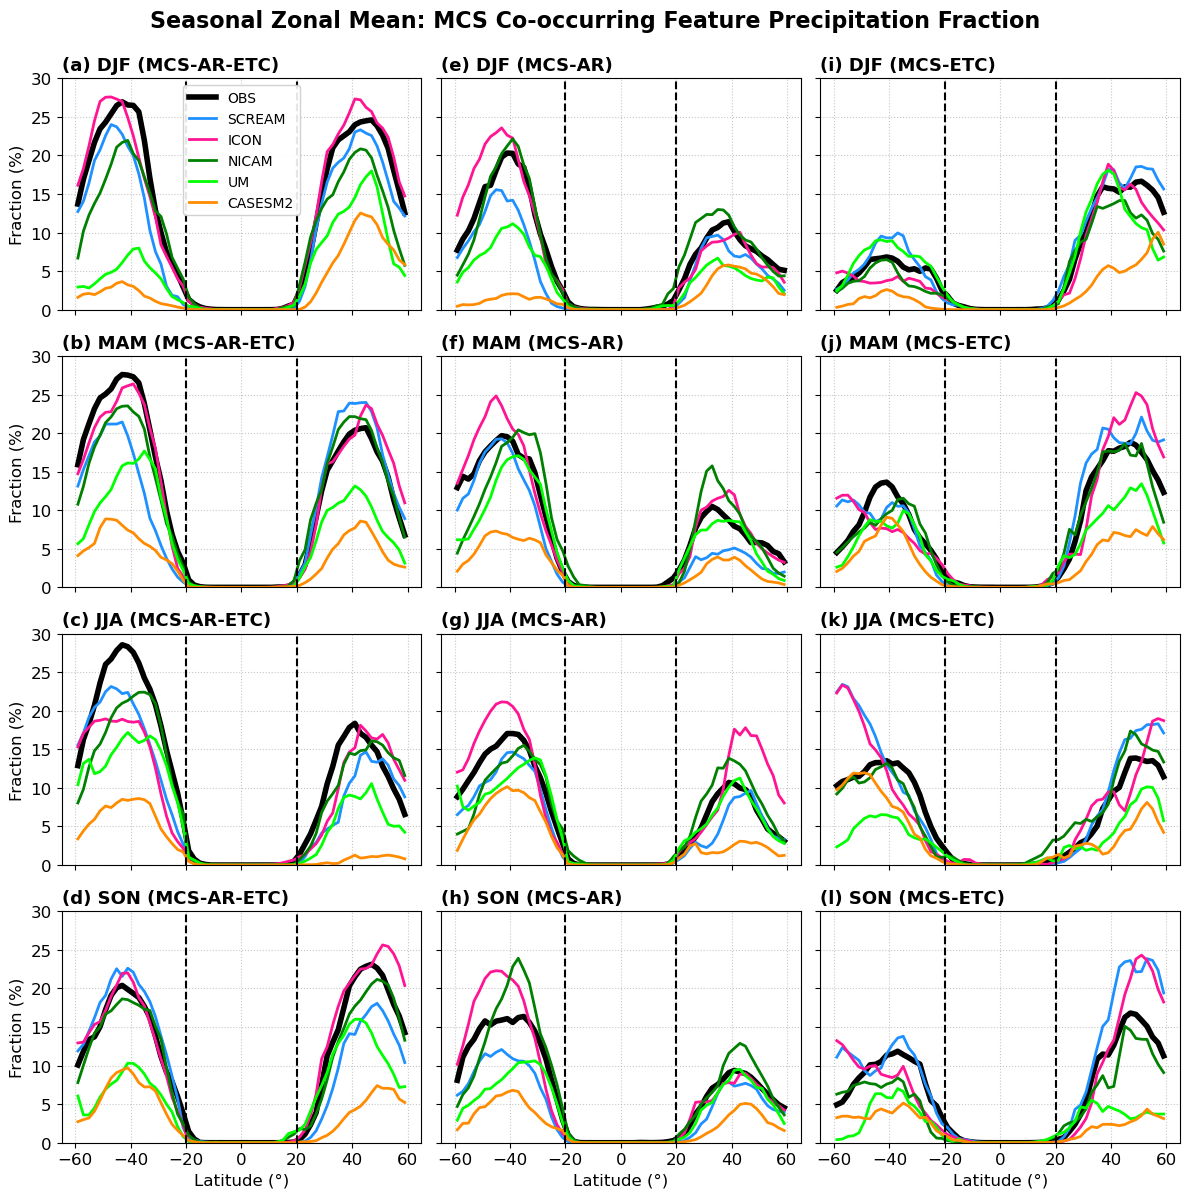

In [31]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    [mcs_ar_etc_pcpfrac_zonal.sel(season='DJF'), mcs_ar_pcpfrac_zonal.sel(season='DJF'), mcs_etc_pcpfrac_zonal.sel(season='DJF')],
    [mcs_ar_etc_pcpfrac_zonal.sel(season='MAM'), mcs_ar_pcpfrac_zonal.sel(season='MAM'), mcs_etc_pcpfrac_zonal.sel(season='MAM')],
    [mcs_ar_etc_pcpfrac_zonal.sel(season='JJA'), mcs_ar_pcpfrac_zonal.sel(season='JJA'), mcs_etc_pcpfrac_zonal.sel(season='JJA')],
    [mcs_ar_etc_pcpfrac_zonal.sel(season='SON'), mcs_ar_pcpfrac_zonal.sel(season='SON'), mcs_etc_pcpfrac_zonal.sel(season='SON')]
]

panel_titles = [
    ['(a) DJF (MCS-AR-ETC)', '(e) DJF (MCS-AR)', '(i) DJF (MCS-ETC)'],
    ['(b) MAM (MCS-AR-ETC)', '(f) MAM (MCS-AR)', '(j) MAM (MCS-ETC)'],
    ['(c) JJA (MCS-AR-ETC)', '(g) JJA (MCS-AR)', '(k) JJA (MCS-ETC)'],
    ['(d) SON (MCS-AR-ETC)', '(h) SON (MCS-AR)', '(l) SON (MCS-ETC)'],
]
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS Co-occurring Feature Precipitation Fraction'
figname = f'{figdir}zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models.pdf'
figsize = (12, 12)
legend_loc = 'upper center'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_grid(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2, legend_loc=legend_loc,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
    legend_panels='first', lat_lines=[-20, 20], sharey=True,
)

### Plot zonal mean separately for land vs. ocean

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models_ocean.pdf


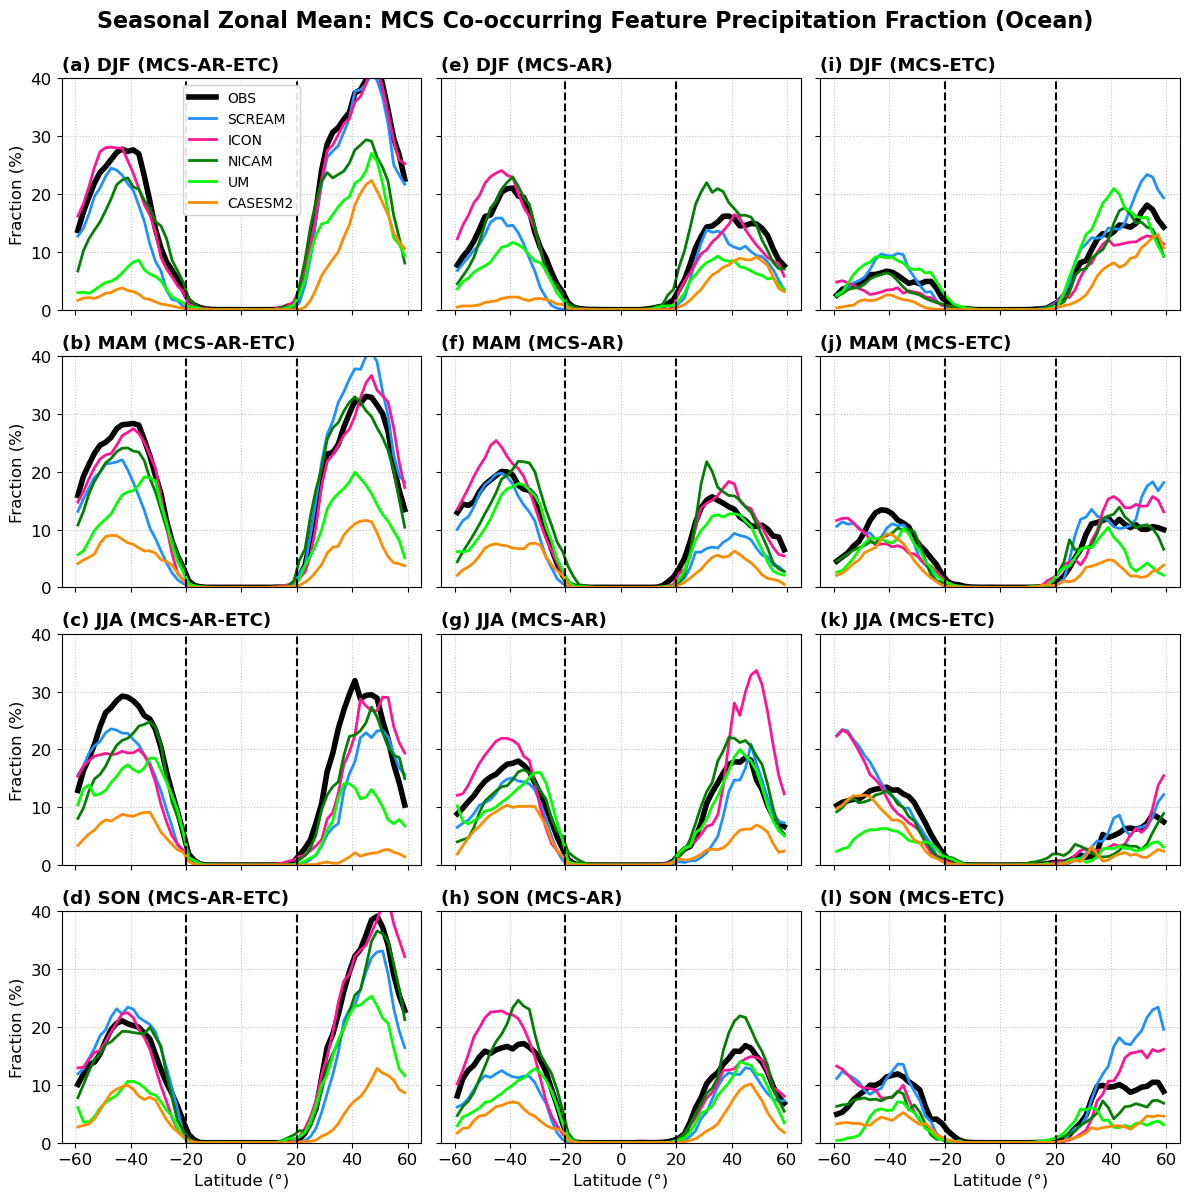

In [32]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    [mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='DJF'), mcs_ar_pcpfrac_zonal_ocean.sel(season='DJF'), mcs_etc_pcpfrac_zonal_ocean.sel(season='DJF')],
    [mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='MAM'), mcs_ar_pcpfrac_zonal_ocean.sel(season='MAM'), mcs_etc_pcpfrac_zonal_ocean.sel(season='MAM')],
    [mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='JJA'), mcs_ar_pcpfrac_zonal_ocean.sel(season='JJA'), mcs_etc_pcpfrac_zonal_ocean.sel(season='JJA')],
    [mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='SON'), mcs_ar_pcpfrac_zonal_ocean.sel(season='SON'), mcs_etc_pcpfrac_zonal_ocean.sel(season='SON')]
]

panel_titles = [
    ['(a) DJF (MCS-AR-ETC)', '(e) DJF (MCS-AR)', '(i) DJF (MCS-ETC)'],
    ['(b) MAM (MCS-AR-ETC)', '(f) MAM (MCS-AR)', '(j) MAM (MCS-ETC)'],
    ['(c) JJA (MCS-AR-ETC)', '(g) JJA (MCS-AR)', '(k) JJA (MCS-ETC)'],
    ['(d) SON (MCS-AR-ETC)', '(h) SON (MCS-AR)', '(l) SON (MCS-ETC)'],
]
ylabel = 'Fraction (%)'
ylims = (0, 40)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS Co-occurring Feature Precipitation Fraction (Ocean)'
figname = f'{figdir}zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models_ocean.pdf'
figsize = (12, 12)
legend_loc = 'upper center'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_grid(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2, legend_loc=legend_loc,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
    legend_panels='first', lat_lines=[-20, 20], sharey=True,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_202609/zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models_land.pdf


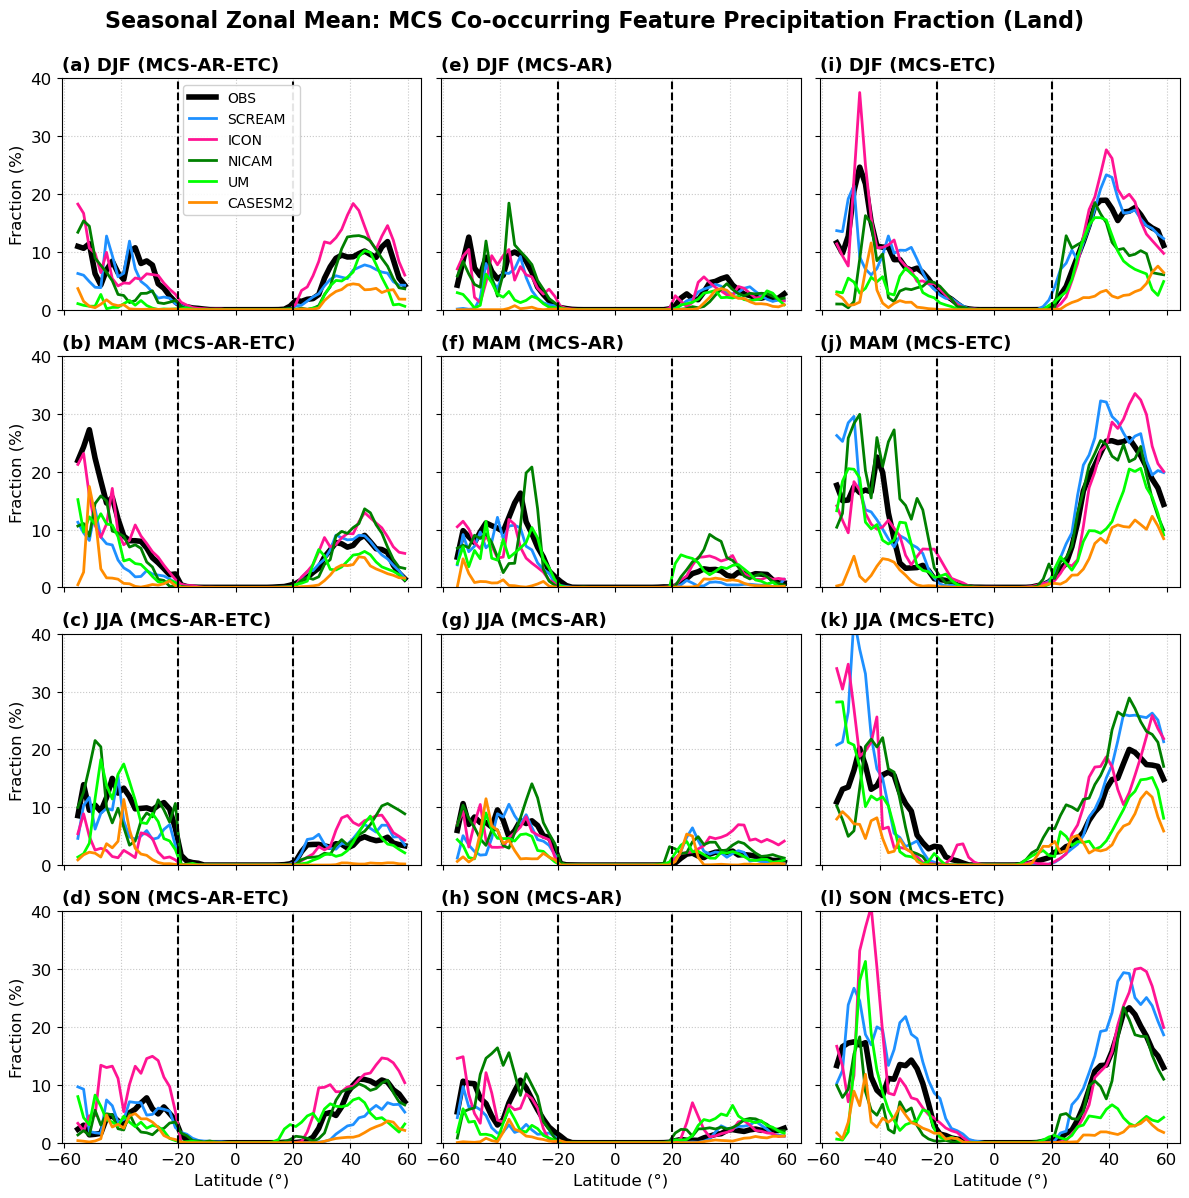

In [33]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    [mcs_ar_etc_pcpfrac_zonal_land.sel(season='DJF'), mcs_ar_pcpfrac_zonal_land.sel(season='DJF'), mcs_etc_pcpfrac_zonal_land.sel(season='DJF')],
    [mcs_ar_etc_pcpfrac_zonal_land.sel(season='MAM'), mcs_ar_pcpfrac_zonal_land.sel(season='MAM'), mcs_etc_pcpfrac_zonal_land.sel(season='MAM')],
    [mcs_ar_etc_pcpfrac_zonal_land.sel(season='JJA'), mcs_ar_pcpfrac_zonal_land.sel(season='JJA'), mcs_etc_pcpfrac_zonal_land.sel(season='JJA')],
    [mcs_ar_etc_pcpfrac_zonal_land.sel(season='SON'), mcs_ar_pcpfrac_zonal_land.sel(season='SON'), mcs_etc_pcpfrac_zonal_land.sel(season='SON')]
]

panel_titles = [
    ['(a) DJF (MCS-AR-ETC)', '(e) DJF (MCS-AR)', '(i) DJF (MCS-ETC)'],
    ['(b) MAM (MCS-AR-ETC)', '(f) MAM (MCS-AR)', '(j) MAM (MCS-ETC)'],
    ['(c) JJA (MCS-AR-ETC)', '(g) JJA (MCS-AR)', '(k) JJA (MCS-ETC)'],
    ['(d) SON (MCS-AR-ETC)', '(h) SON (MCS-AR)', '(l) SON (MCS-ETC)'],
]
ylabel = 'Fraction (%)'
ylims = (0, 40)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS Co-occurring Feature Precipitation Fraction (Land)'
figname = f'{figdir}zonalmean_mcs_3COFtype_rainfrac_4season_obs_vs_models_land.pdf'
figsize = (12, 12)
legend_loc = 'upper center'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_grid(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2, legend_loc=legend_loc,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
    legend_panels='first', lat_lines=[-20, 20], sharey=True,
)

## Plot multiple maps

In [34]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [35]:
def plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname, 
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None, 
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None, 
                  show_gridlines=False, figtitle=None, dpi=200, lat_lines=None, lat_range=None):
    """
    Plot a grid of maps with flexible dimensions
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    lat_lines : list or None
        List of latitude values to plot as horizontal lines (e.g., [-20, 20] for tropics)
    lat_range : tuple
        (lat_min, lat_max) for displayed latitude range.
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")
    
    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                ax.set_title(titles[row][col], fontsize=fontsize, loc='left')
                # flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                # flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))          
                
                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))
                
                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])
                
                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                
                # Plot data
                if not contourf:
                    cf1 = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)            
                else:
                    cf1 = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)
                
                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
                
                if lat_range is not None:
                    lat_min, lat_max = lat_range
                    _, y_min = proj.transform_point(0, lat_min, ccrs.PlateCarree())
                    _, y_max = proj.transform_point(0, lat_max, ccrs.PlateCarree())
                    ax.set_ylim([y_min, y_max])

                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col], 
                           orientation='vertical', extend='both')
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

In [36]:
# tropics_lat = (-20, 20)
# lat_range = (-60, 60)

# # Create 2D lists for data and titles
# season = 'DJF'
# da_list = [
#     [mcs_pcpfrac_season.sel(source='obs', season=season), mcs_pcpfrac_season.sel(source='m1', season=season)],
#     [mcs_pcpfrac_season.sel(source='m2', season=season), mcs_pcpfrac_season.sel(source='m3', season=season)],
#     [mcs_pcpfrac_season.sel(source='m4', season=season), mcs_pcpfrac_season.sel(source='m5', season=season)],
# ]
# titles = [
#     [f"(a) {name_map_plot['obs']}", f"(b) {name_map_plot['m1']}"],
#     [f"(c) {name_map_plot['m2']}", f"(d) {name_map_plot['m3']}"],
#     [f"(e) {name_map_plot['m4']}", f"(f) {name_map_plot['m5']}"]
# ]

# # Setup grid parameters
# nrow = len(da_list)
# ncol = len(da_list[0]) if nrow > 0 else 1
# figwidth = 14
# height_ratio_per_panel = 0.4
# figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
# figsize = [figwidth, figheight]
# fontsize = 12
# cb_fontsize = 10
# wspace = 0.02
# hspace = 0.03
# varname1 = 'Fraction'
# units = '%'
# figtitle = f'All MCS Contribution to Total Precipitation ({season})'
# lat_lines = tropics_lat

# # Setup levels and colormap
# levels = np.arange(0, 81, 10)
# min_thresh = None
# colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
# cbticks = levels
# oob_colors = {'over':'firebrick', 'under':'white'}
# cblabels = f'{varname1} ({units})'
# figname = f'{figdir}globalmap_mcs_all_rainfrac_{season}.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, show_gridlines=False, dpi=200)
# print(figname)

In [37]:
# # Create 2D lists for data and titles
# season = 'JJA'
# da_list = [
#     [mcs_pcpfrac_season.sel(source='obs', season=season), mcs_pcpfrac_season.sel(source='m1', season=season)],
#     [mcs_pcpfrac_season.sel(source='m2', season=season), mcs_pcpfrac_season.sel(source='m3', season=season)],
#     [mcs_pcpfrac_season.sel(source='m4', season=season), mcs_pcpfrac_season.sel(source='m5', season=season)],
# ]
# figtitle = f'All MCS Contribution to Total Precipitation ({season})'
# figname = f'{figdir}globalmap_mcs_all_rainfrac_{season}.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, show_gridlines=False, dpi=200)
# print(figname)

In [38]:
# # Create 2D lists for data and titles
# season = 'MAM'
# da_list = [
#     [mcs_pcpfrac_season.sel(source='obs', season=season), mcs_pcpfrac_season.sel(source='m1', season=season)],
#     [mcs_pcpfrac_season.sel(source='m2', season=season), mcs_pcpfrac_season.sel(source='m3', season=season)],
#     [mcs_pcpfrac_season.sel(source='m4', season=season), mcs_pcpfrac_season.sel(source='m5', season=season)],
# ]
# figtitle = f'All MCS Contribution to Total Precipitation ({season})'
# figname = f'{figdir}globalmap_mcs_all_rainfrac_{season}.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, show_gridlines=False, dpi=200)
# print(figname)

In [39]:
# # Create 2D lists for data and titles
# season = 'SON'
# da_list = [
#     [mcs_pcpfrac_season.sel(source='obs', season=season), mcs_pcpfrac_season.sel(source='m1', season=season)],
#     [mcs_pcpfrac_season.sel(source='m2', season=season), mcs_pcpfrac_season.sel(source='m3', season=season)],
#     [mcs_pcpfrac_season.sel(source='m4', season=season), mcs_pcpfrac_season.sel(source='m5', season=season)],
# ]
# figtitle = f'All MCS Contribution to Total Precipitation ({season})'
# figname = f'{figdir}globalmap_mcs_all_rainfrac_{season}.png'

# # Plot figure
# fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
#                     figtitle=figtitle, lat_lines=lat_lines, lat_range=lat_range,
#                     min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
#                     fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
#                     oob_colors=oob_colors, show_gridlines=False, dpi=200)
# print(figname)